<font color="#CA0032"><h1 align="left">**Dataset completo de competición Rossmann de Kaggle**</h1></font>

https://www.kaggle.com/competitions/rossmann-store-sales/data?select=store.csv</h1></font>

Descargado de:

https://github.com/sarthaksoni25/Rossmann-Store-Sales-Prediction/tree/master/dataset

El objetivo del ejercicio es construir un modelo de predicción de ventas en las siguientes 10 tiendas:

* 1,2,3,4,5,562,682,733,769

El objetivo es obtener en test el mayor $R^2$ posible.

El conjunto de test serán los datos a partir del 1 de enero de 2015 (incluido).

No se podrá usar como variable de entrada la variable "Customers".


### **Usaremos un esquema many to one:**

<img src="https://drive.google.com/uc?export=download&id=1iokh576AiK2iFhftPogSBsNXixAi-LBg" align="center" style="float" width="500">

In [1]:
COLAB = False

## <font color="#CA3532"> **1. Importar librerías**

In [5]:
import numpy as np
import pandas as pd

from keras.models import Sequential, load_model
from keras.layers import Dense, LSTM, GRU
from keras.callbacks import ModelCheckpoint

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score as R2_score

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

import os
from my_utils_series_temporales import int2dummy, enventanar, info_enventanado, NAN
from sklearn.preprocessing import LabelEncoder

# fijo la semilla aleatoria por reproducibilidad
np.random.seed(7)

## <font color="#CA3532"> **2. Carga de datos**

Leemos los datos. En este caso, solo utilizaremos los datos de train_data.

In [6]:
if COLAB:
    download_file_from_google_drive(file_id='19C18QXw0VtfBm_k6fqaI_nf1RH1Larw1', dest_file='./store.csv')
    download_file_from_google_drive(file_id='1tg-VNN-s8PwE0eOY6TjjQ5-Orv8kPAqB', dest_file='./train.csv')

store_data = pd.read_csv('data/store.csv')
train_data = pd.read_csv('data/train.csv')
test_data = pd.read_csv('data/test.csv')
submission =  pd.read_csv('data/submission.csv')

C:\Users\mateo\AppData\Local\Temp\ipykernel_19916\3680908188.py:6: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv('data/train.csv')


In [268]:
store_data.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [269]:
train_data.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
0,1,5,2015-07-17,4852,519,1,1,0,0,303445
1,2,5,2015-07-17,4518,495,1,1,0,1,959585
2,3,5,2015-07-17,6679,673,1,1,0,1,739744
3,4,5,2015-07-17,10514,1343,1,1,0,1,864001
4,5,5,2015-07-17,4355,513,1,1,0,1,981931


In [270]:
test_data.head()

,Id,Store,DayOfWeek,Date,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,879066,1,5,2015-07-31,555,1,1,0,1
1,37135,2,5,2015-07-31,625,1,1,0,1
2,285919,3,5,2015-07-31,821,1,1,0,1
3,744348,4,5,2015-07-31,1498,1,1,0,1
4,556250,5,5,2015-07-31,559,1,1,0,1


## <font color="#CA3532"> **3. Filtrado por las tiendas de interés**

Filtramos por las tiendas que nos interesan: 1,2,3,4,5,562,682,733 y 769.

In [7]:
tiendas = [1,2,3,4,5,562,682,733,769]
datasets = [store_data, train_data, test_data]
nombre_datasets = ['store_data', 'train_data', 'test_data']
dict_datasets = dict(zip(nombre_datasets, datasets))

Solo hay valores nulos en el dataset store data

In [8]:
for key, value in dict_datasets.items():
    print(f'Valores nulos del dataset {key}: {value.isna().sum().sum()}')

Valores nulos del dataset store_data: 2343
Valores nulos del dataset train_data: 0
Valores nulos del dataset test_data: 0


In [9]:
datasets_filtrados = []

for dataset in datasets:
    # Filtramos por los id de las tiendas
    datasets_filtrados.append(dataset[dataset['Store'].isin(tiendas)])

dict_data = dict(zip(nombre_datasets, datasets_filtrados))

In [10]:
# Valores nulos para cada dataset
for dataset in datasets_filtrados:
    print(dataset.isna().sum().sum())

22
0
0


Observamos que los valores nulos de los datos de las tiendas `store data` se encuentran en las columnas: 

- `CompetitionOpenSinceMonth`: Faltan los datos de los competidores de las tiendas 562 y 769.
- `CompetitionOpenSinceYear`: Faltan los datos de los competidores de las tiendas 562 y 769.
- `Promo2SinceWeek`
- `Promo2SinceWeek`
- `PromoInterval`

A continuación, se muestra para cada gráfica el número de ventas para cada tienda durante el periodo en el que tenemos datos.

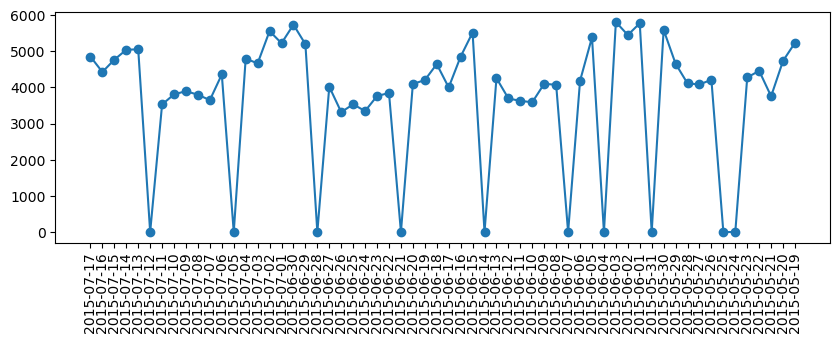

928


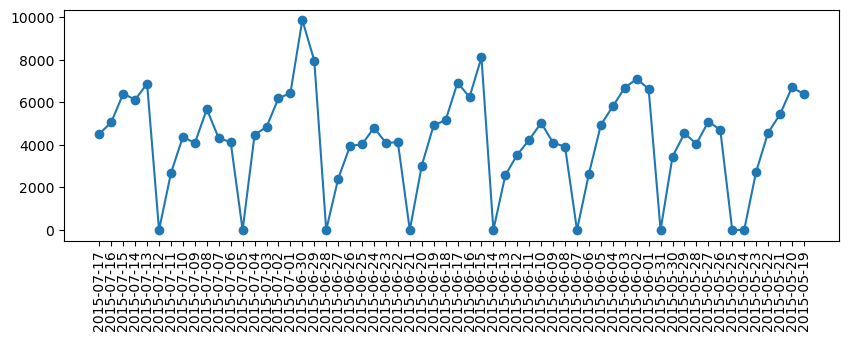

928


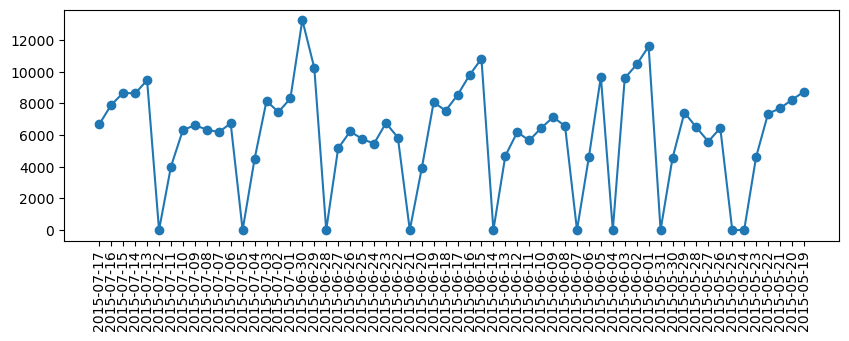

928


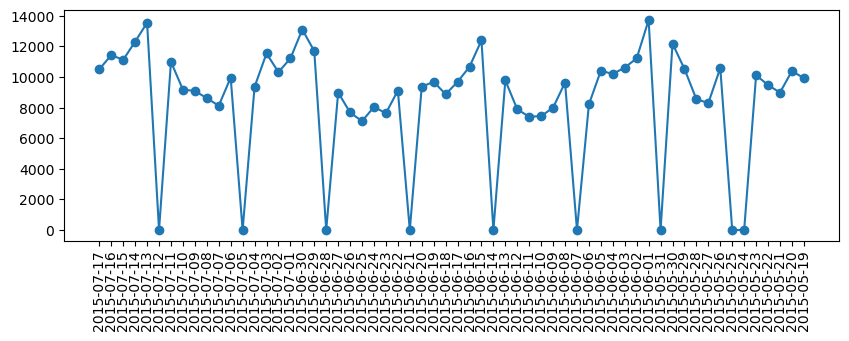

928


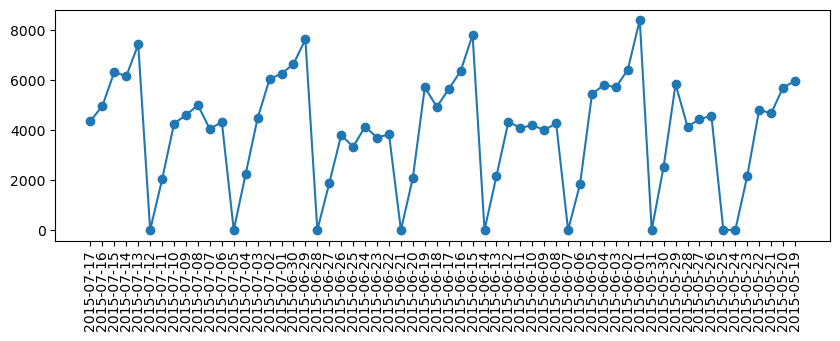

928


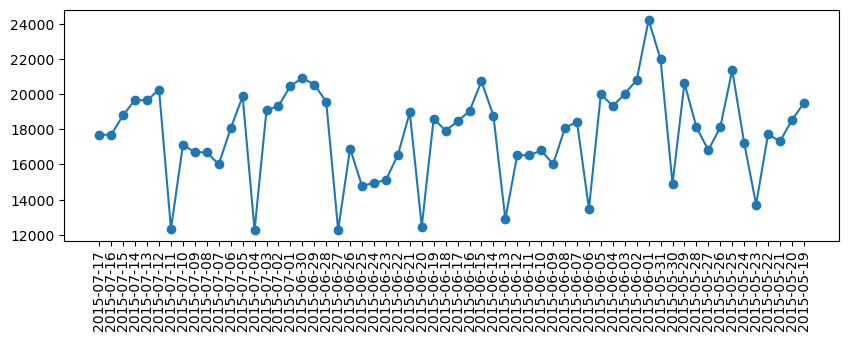

928


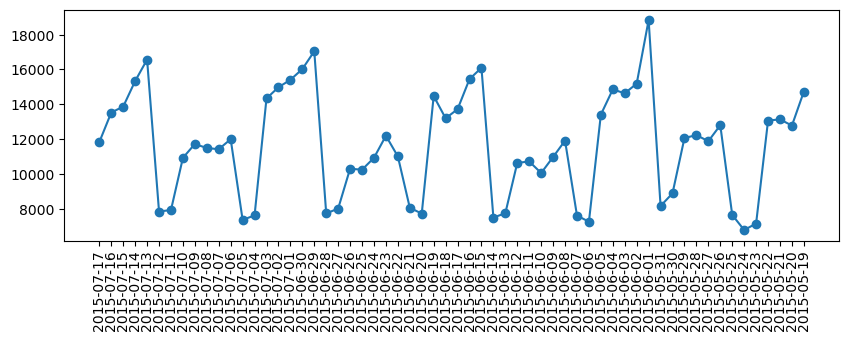

928


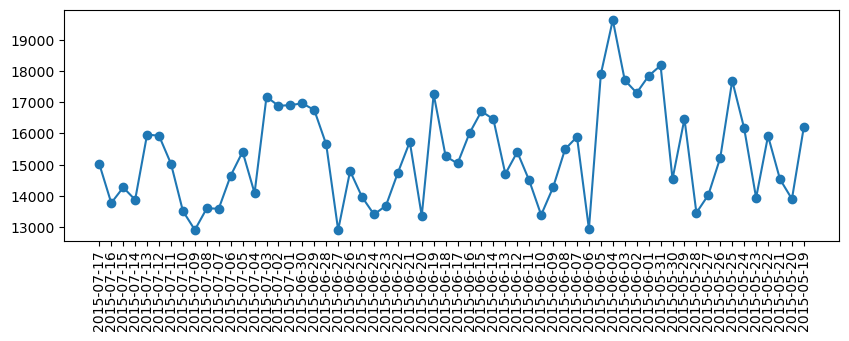

928


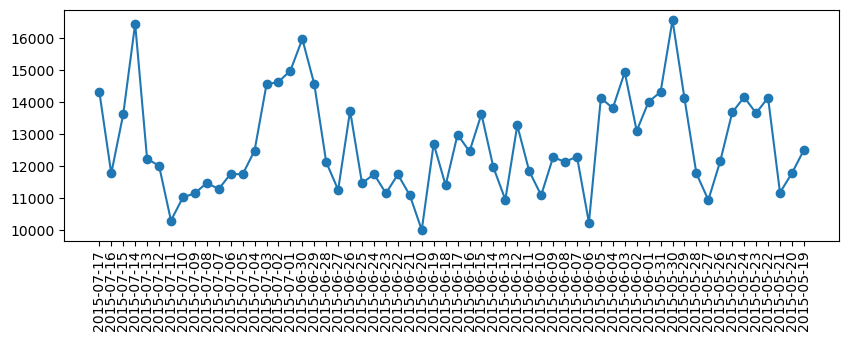

928


In [11]:
for store_id in [1,2,3,4,5,562,682,733,769]:
  aux = train_data[train_data["Store"]==store_id]
  plt.figure(figsize=(10,3))
  plt.plot(aux["Date"][:60], aux["Sales"][:60], "o-")
  plt.xticks(rotation=90)
  plt.show()
  print(len(aux))

Gracias a la función `value_counts()` podemos observar para las variables categóricas, cuantas categorías tienen para realizar el debido procesamiento. 

Destaca la variable `StateHoliday` que tiene como categoría 0 y '0'. Consideramos que significan lo mismo, así que las agruparemos para el procesamiento de esta variable categórica multiclase.

In [12]:
for dataset in datasets_filtrados[:2]:
    for column in dataset.columns:
        print(dataset[column].value_counts())
    print('****************************************')

Store
1      1
2      1
3      1
4      1
5      1
562    1
682    1
733    1
769    1
Name: count, dtype: int64
StoreType
b    4
a    3
c    2
Name: count, dtype: int64
Assortment
a    5
c    2
b    2
Name: count, dtype: int64
CompetitionDistance
1270.0     1
570.0      1
14130.0    1
620.0      1
29910.0    1
1210.0     1
150.0      1
860.0      1
840.0      1
Name: count, dtype: int64
CompetitionOpenSinceMonth
9.0     3
11.0    1
12.0    1
4.0     1
10.0    1
Name: count, dtype: int64
CompetitionOpenSinceYear
2006.0    2
2008.0    1
2007.0    1
2009.0    1
2015.0    1
1999.0    1
Name: count, dtype: int64
Promo2
0    6
1    3
Name: count, dtype: int64
Promo2SinceWeek
13.0    1
14.0    1
48.0    1
Name: count, dtype: int64
Promo2SinceYear
2010.0    1
2011.0    1
2012.0    1
Name: count, dtype: int64
PromoInterval
Jan,Apr,Jul,Oct    3
Name: count, dtype: int64
****************************************
Store
1      928
2      928
3      928
4      928
5      928
562    928
682    928
73

Mostramos los boxplots de la variable Sales respecto a las variables categóricas para cada tienda.

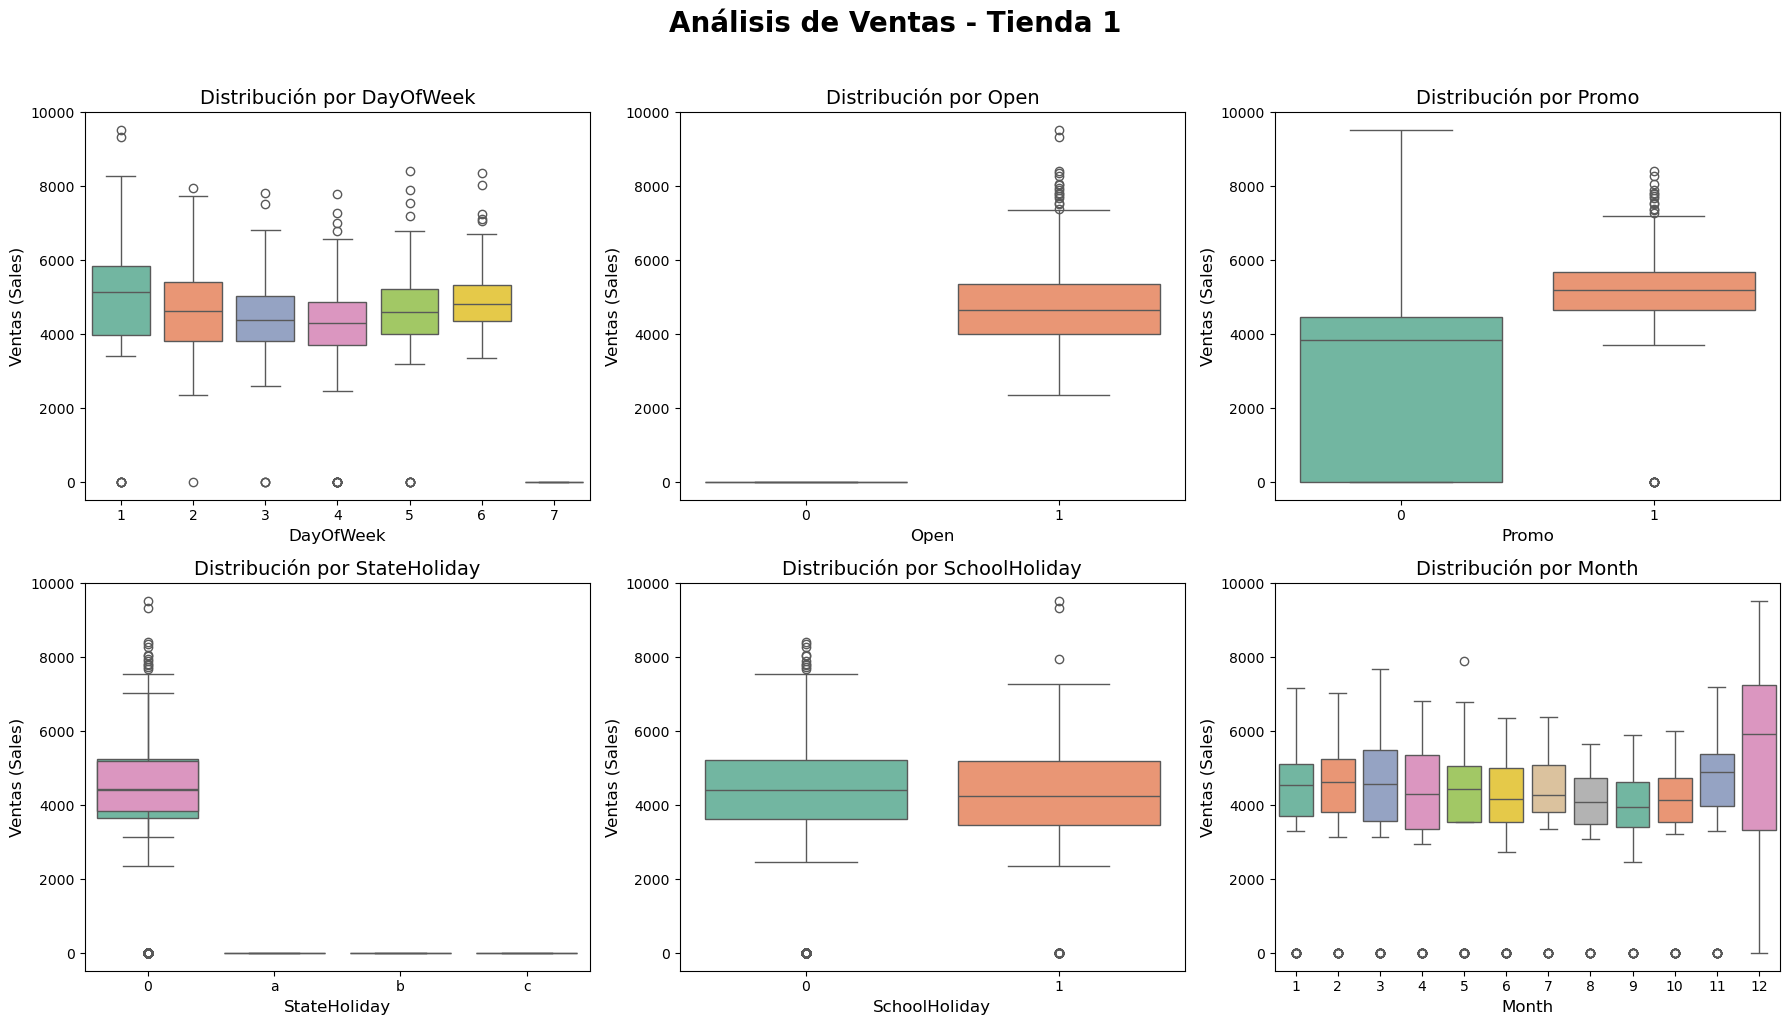

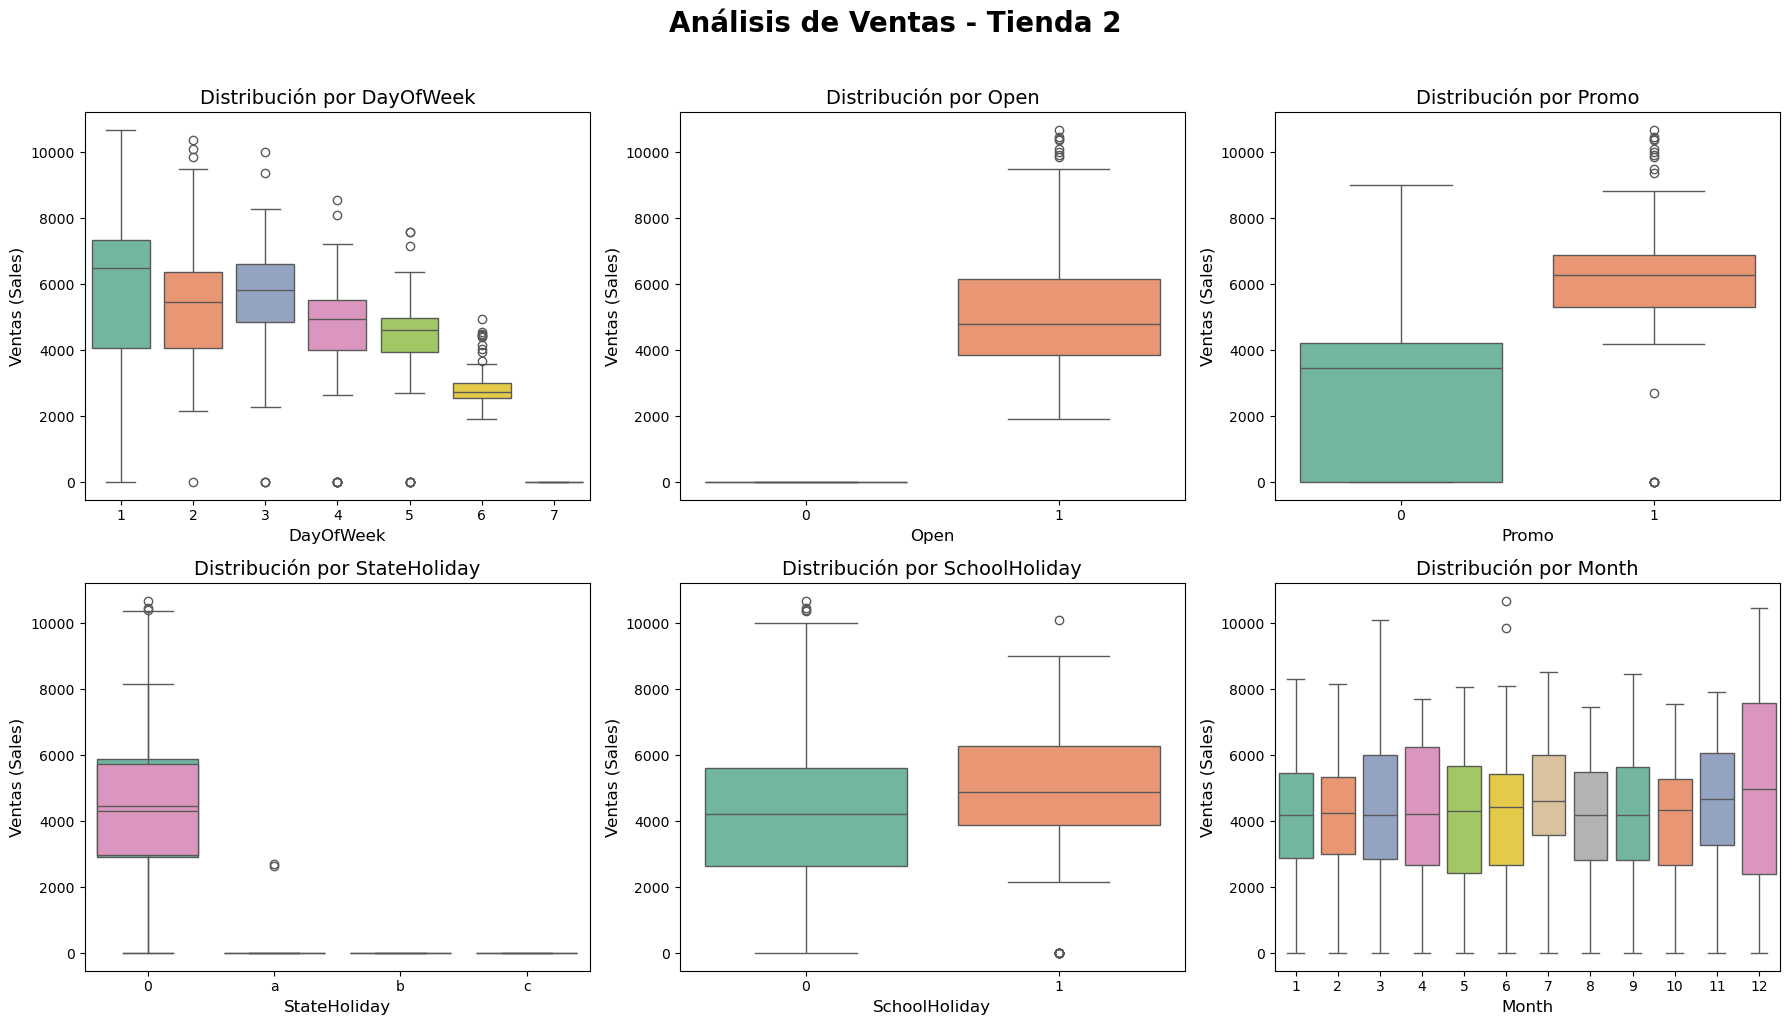

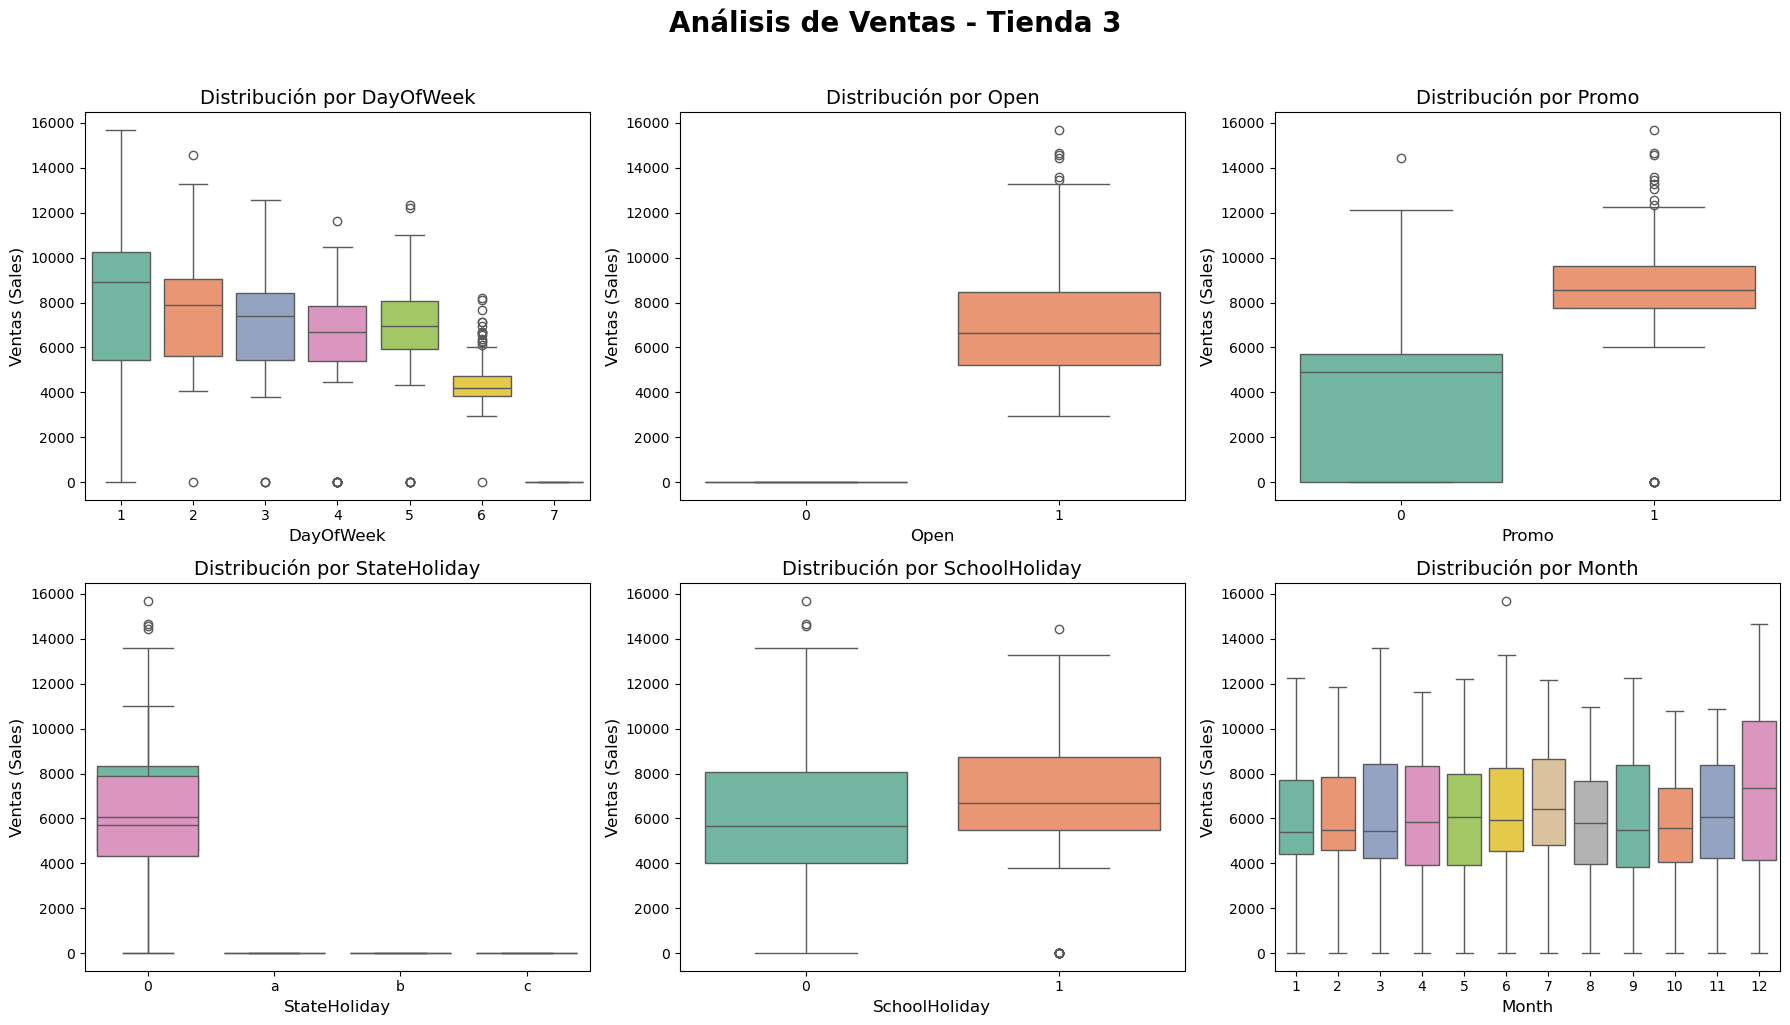

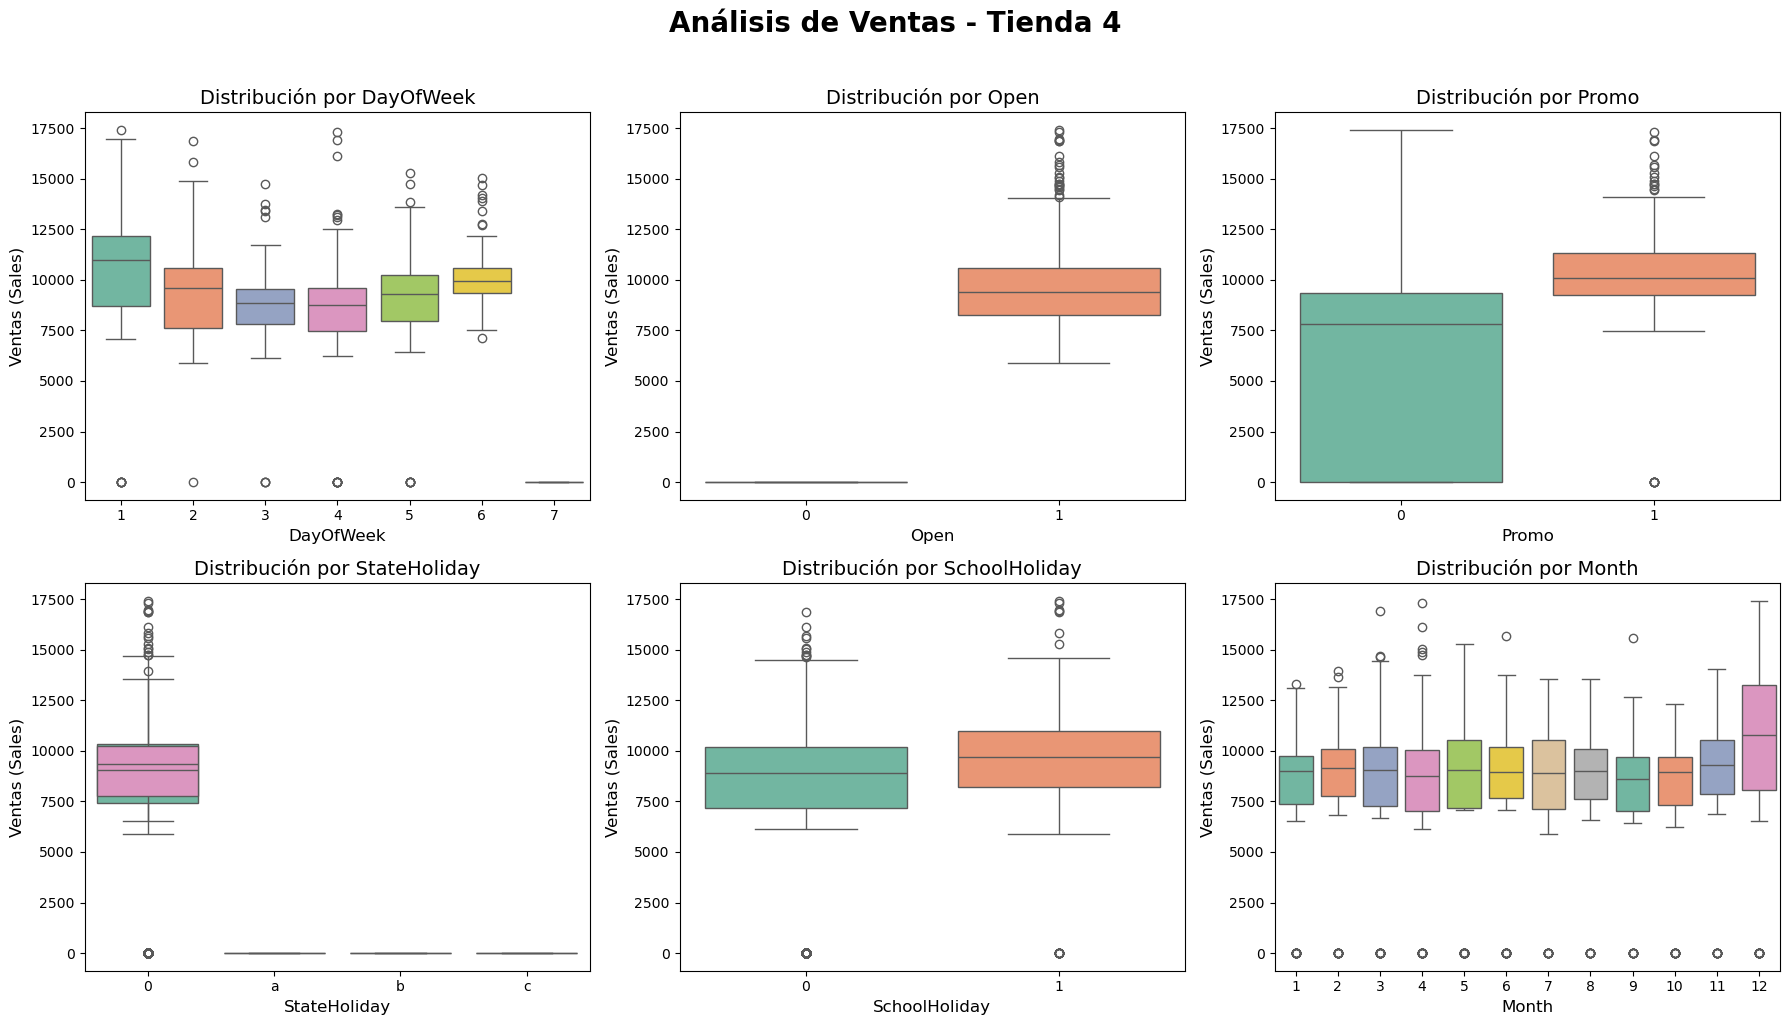

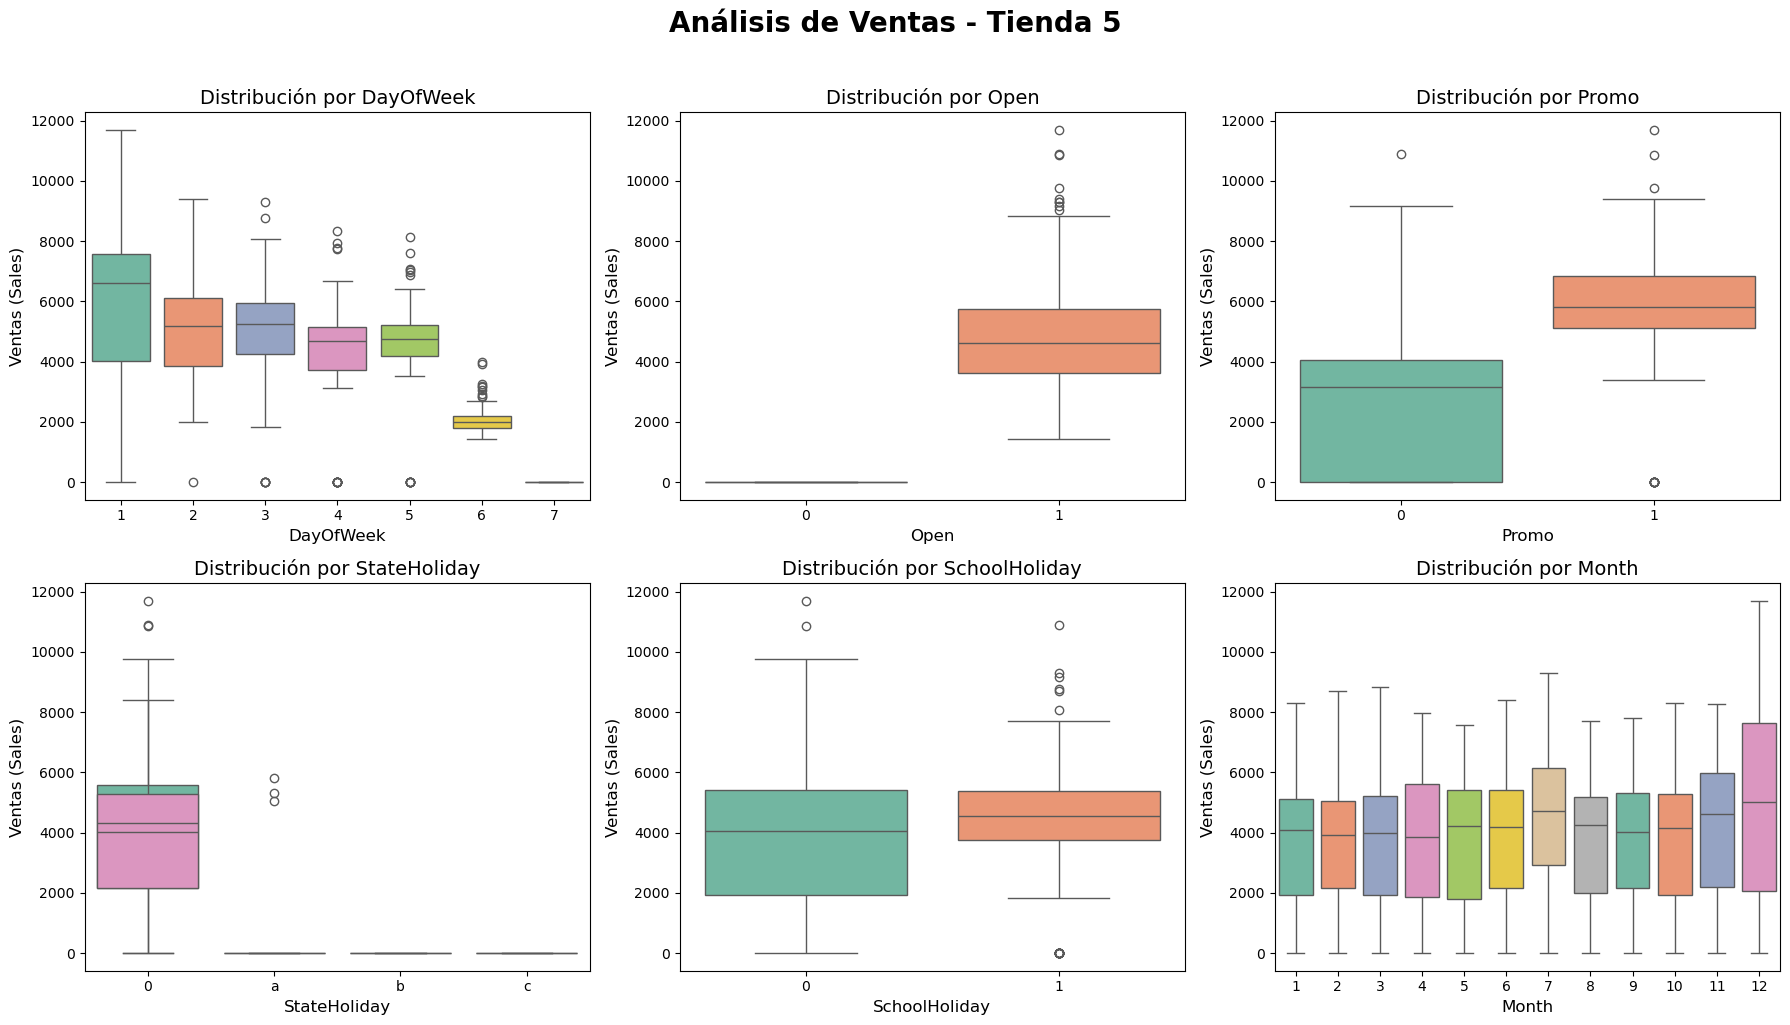

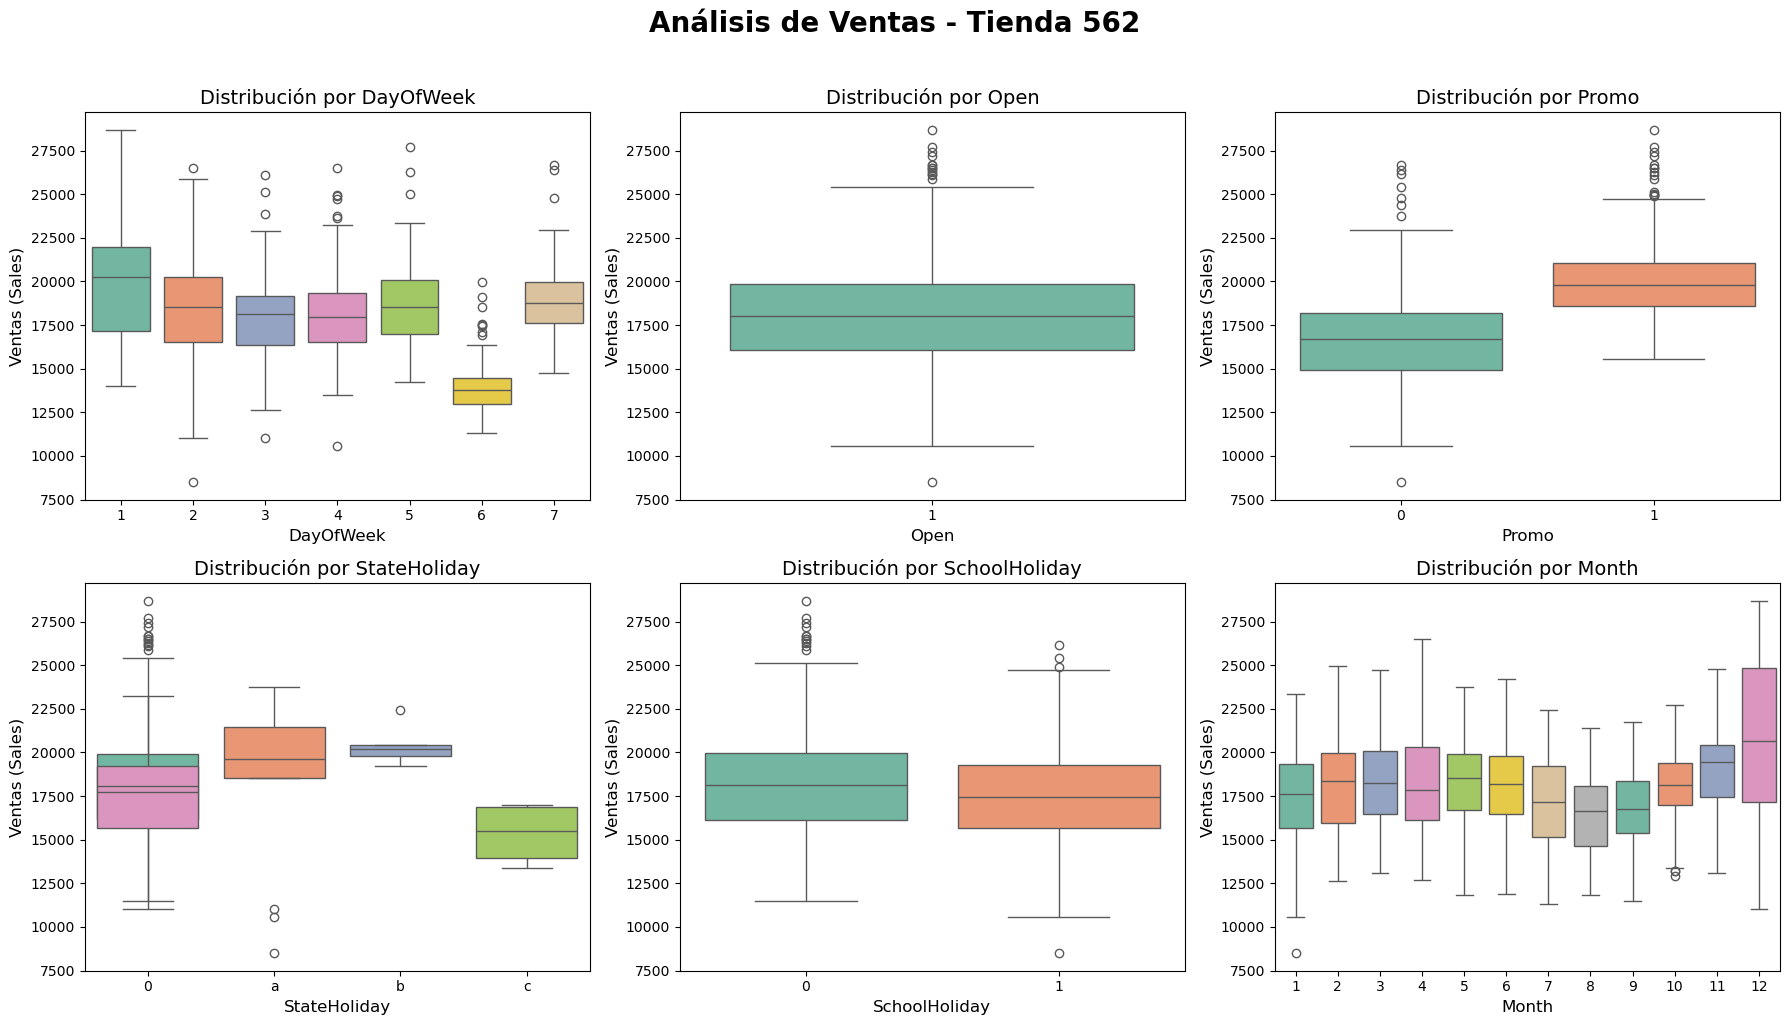

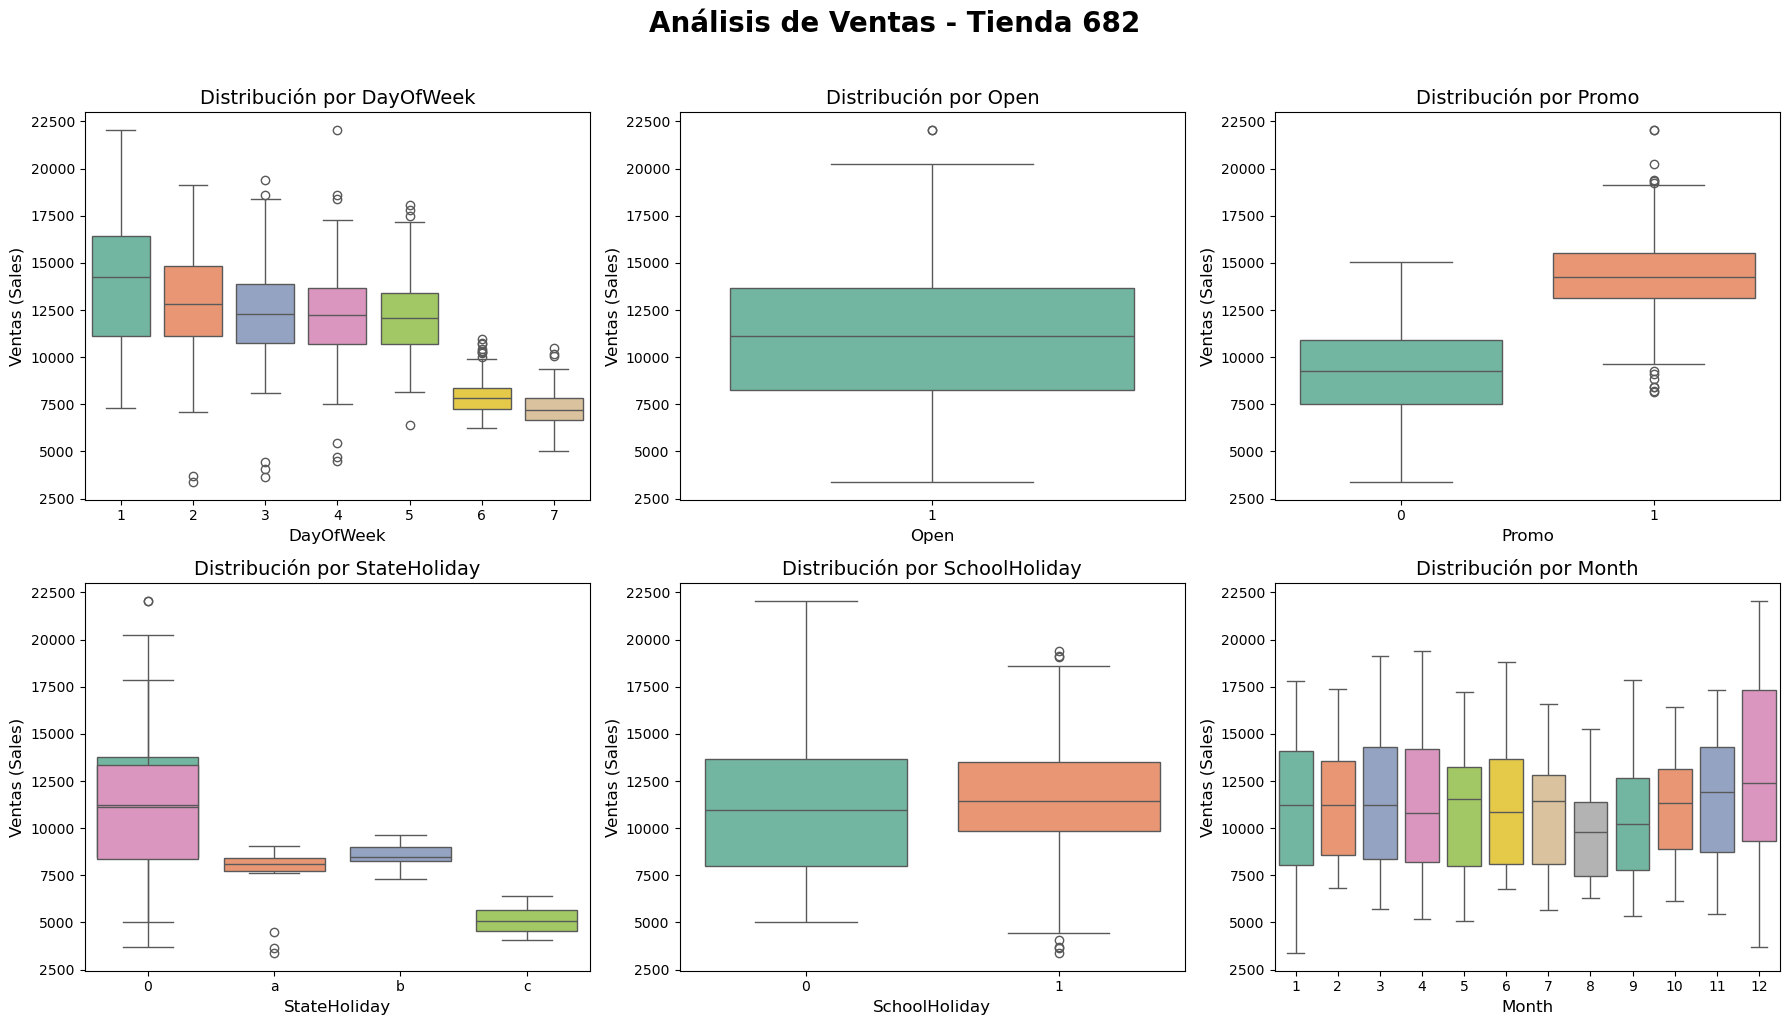

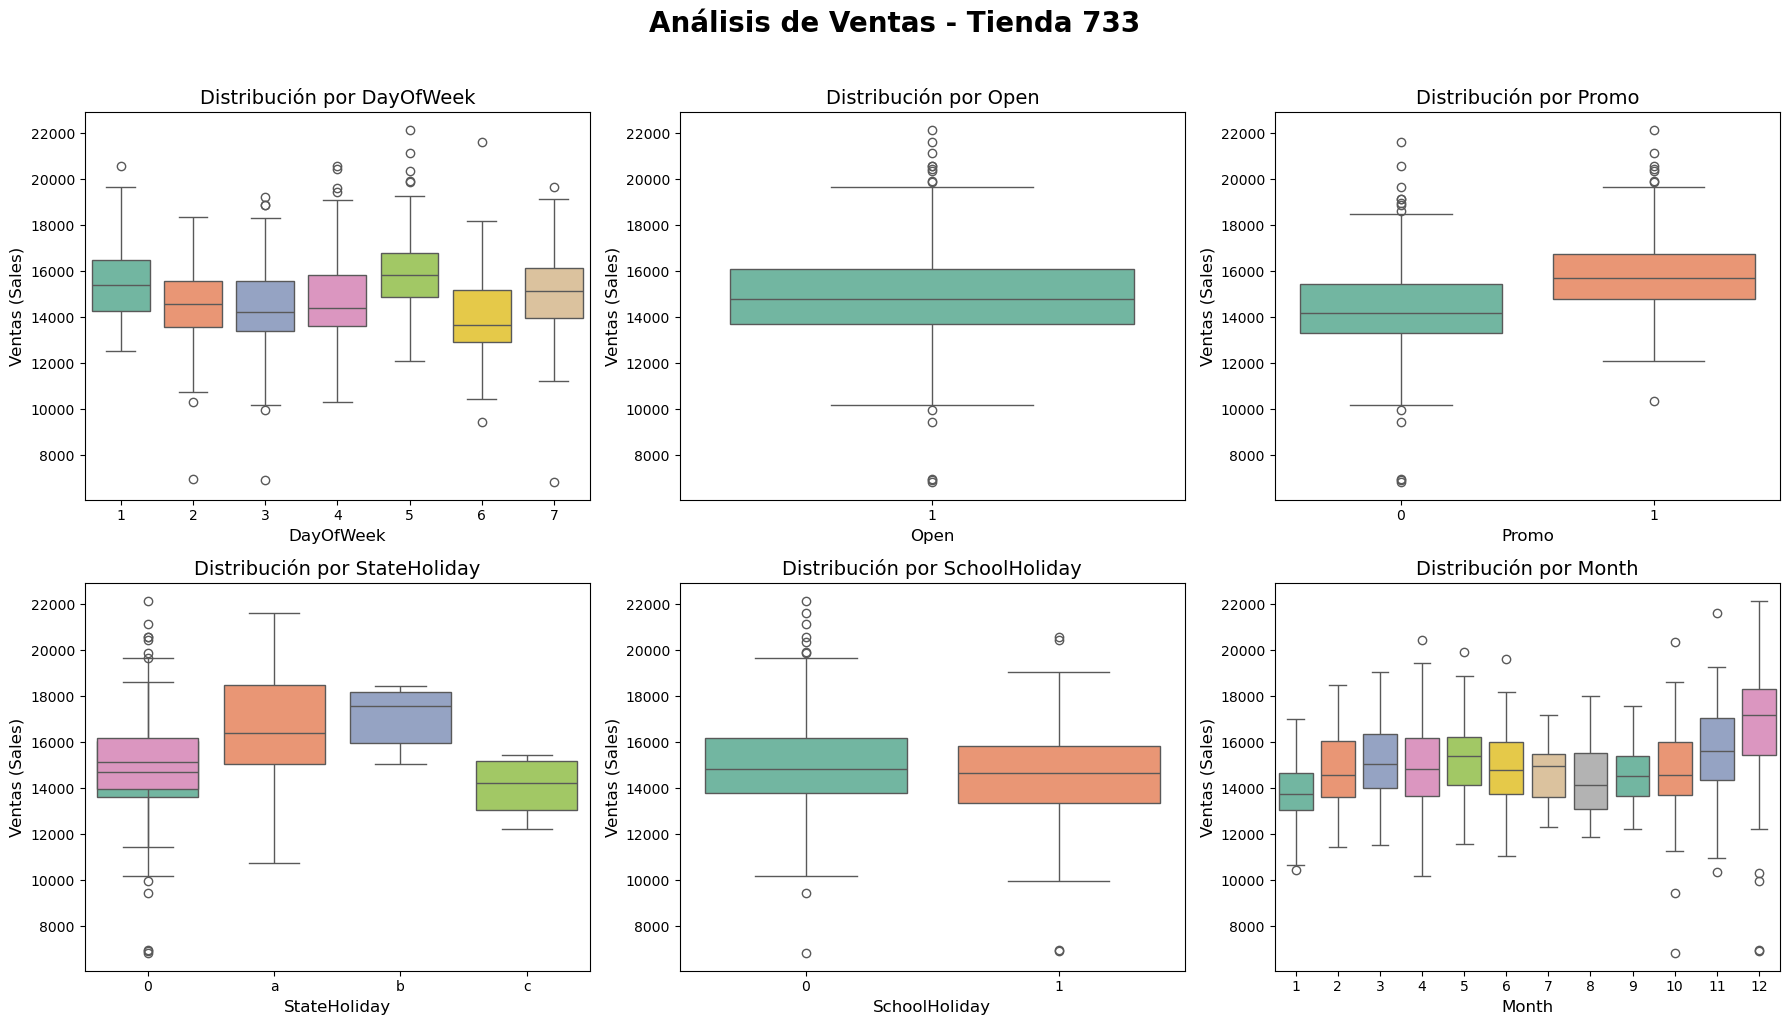

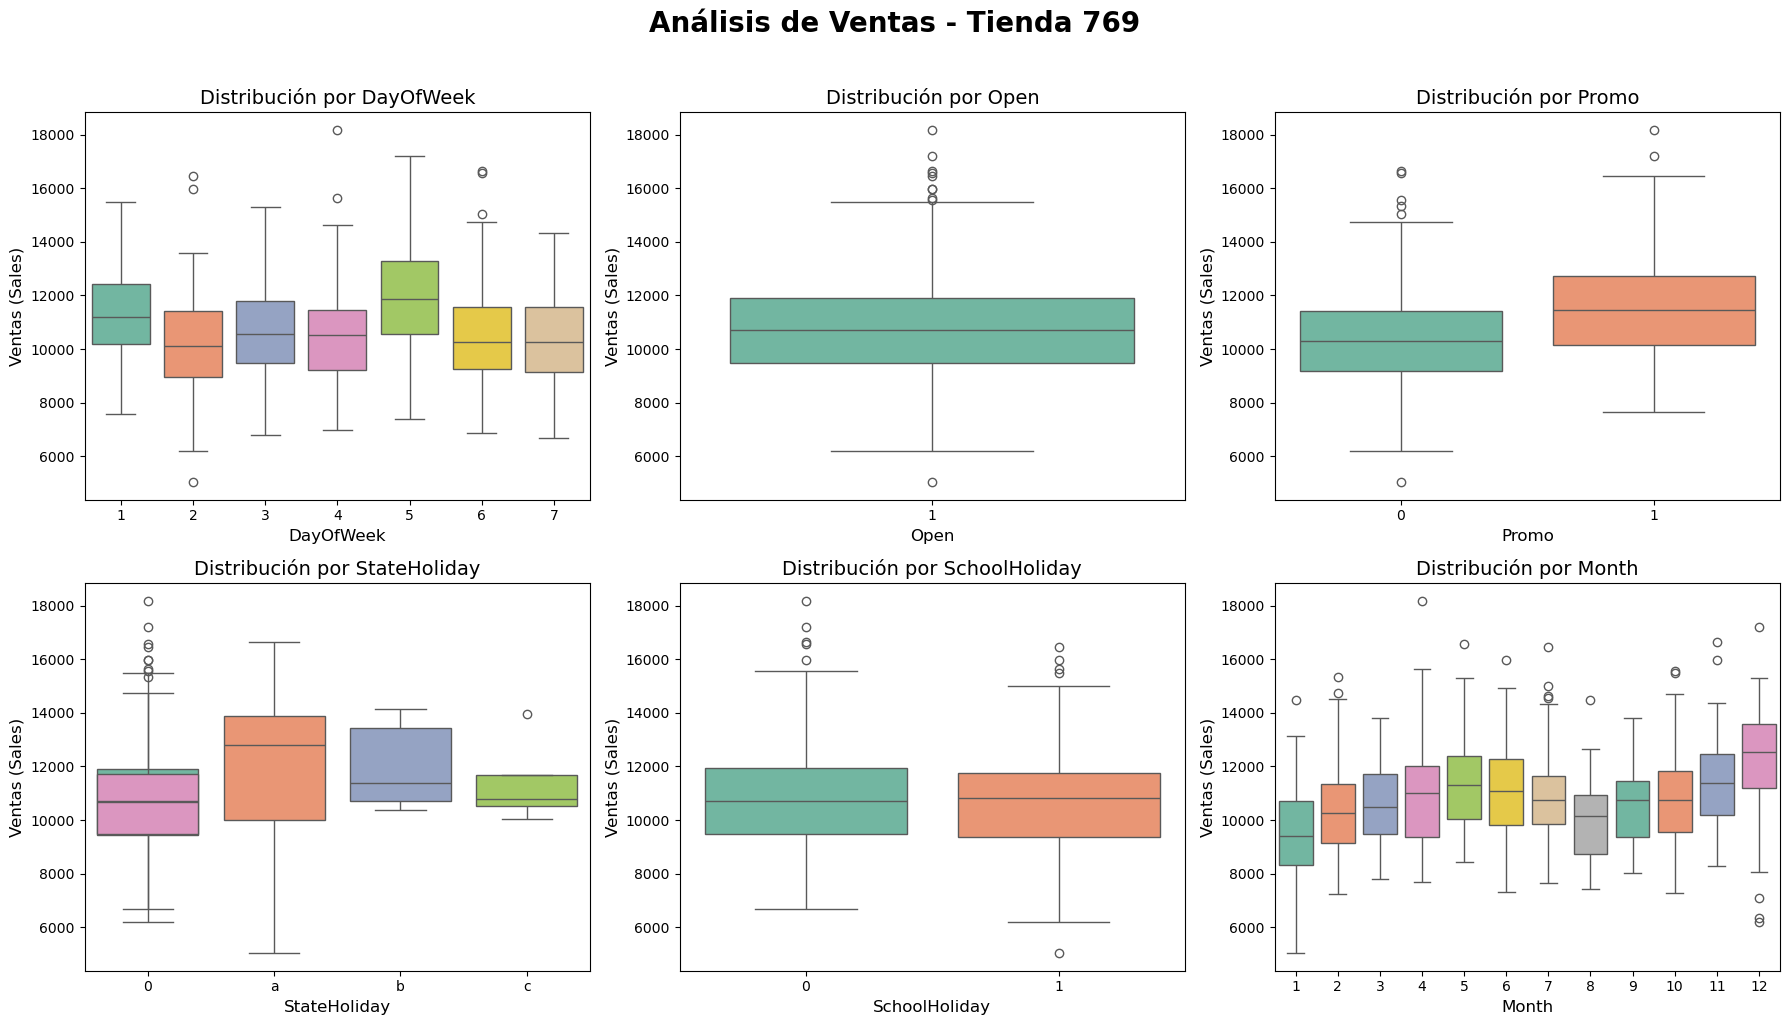

In [13]:
# 1. Definir la lista de tiendas objetivo
tiendas = [1, 2, 3, 4, 5, 562, 682, 733, 769]

# 2. Nos aseguramos de tener la columna Month
if 'Month' not in train_data.columns and 'Date' in train_data.columns:
    train_data['Date'] = pd.to_datetime(train_data['Date'])
    train_data['Month'] = train_data['Date'].dt.month

# 3. Lista de variables categóricas a iterar
vars_categoricas = ['DayOfWeek', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Month']

# 4. Bucle principal: Iteramos por cada tienda individual
for tienda in tiendas:
    # Filtramos los datos SOLO para la tienda actual en esta iteración
    df_tienda = train_data[train_data['Store'] == tienda].copy()
    
    # Creamos una figura nueva para esta tienda
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
    axes = axes.flatten()
    
    # Añadimos un título principal (Super Title) para identificar de qué tienda es el panel
    fig.suptitle(f'Análisis de Ventas - Tienda {tienda}', fontsize=20, fontweight='bold', y=1.02)
    
    # 5. Bucle secundario: Generamos los 6 boxplots para la tienda actual
    for i, var in enumerate(vars_categoricas):
        # Es posible que una tienda nunca abra en festivo y esa categoría falte. 
        # Seaborn lo maneja bien, pero usamos df_tienda
        sns.boxplot(data=df_tienda, x=var, y='Sales', hue=var, ax=axes[i], palette='Set2', legend=False)
        
        # Formato y etiquetas
        axes[i].set_title(f'Distribución por {var}', fontsize=14)
        axes[i].set_xlabel(var, fontsize=12)
        axes[i].set_ylabel('Ventas (Sales)', fontsize=12)

    # 6. Ajustar diseño y mostrar la figura completa de esta tienda ANTES de pasar a la siguiente
    plt.tight_layout()
    plt.show()

## <font color="#CA3532"> **4. Selección del dataset final para cada tienda**

Usamos las variables de `train_data`. En este caso las variables de `store_data` no nos aportan nada porque tienen varianza cero y porque vamos a entrenar los modelos por separado. Seleccionamos las variables que necesitamos y le aplicamos el preprocesamiento que sea necesario.

In [14]:
# Creamos las variables X e y que contendran los datos para entrenar los modelos.
X = datasets_filtrados[1]
#y = X['Sales']

X['Month'] = pd.to_datetime(X['Date']).dt.month
X = X.sort_values(['Date', 'Store'])
X = X.set_index(X['Date'])
y = X['Sales']
X = X.drop(columns=['Date', 'Id', 'Sales', 'Customers'])

C:\Users\mateo\AppData\Local\Temp\ipykernel_19916\2430985127.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Month'] = pd.to_datetime(X['Date']).dt.month


Observamos que todas las variables tienen una estructura adecuada excepto la variable `StateHoliday`. A esta variable le aplicaremos un `LabelEncoder` para codificarla adecuadamente.

In [15]:
for column in X.columns:
    print(column)
    print(X[column].value_counts())

Store
Store
1      928
2      928
3      928
4      928
5      928
562    928
682    928
733    928
769    928
Name: count, dtype: int64
DayOfWeek
DayOfWeek
2    1197
3    1197
4    1197
5    1197
6    1188
7    1188
1    1188
Name: count, dtype: int64
Open
Open
1    7559
0     793
Name: count, dtype: int64
Promo
Promo
0    5157
1    3195
Name: count, dtype: int64
StateHoliday
StateHoliday
0    6420
0    1690
a     152
b      54
c      36
Name: count, dtype: int64
SchoolHoliday
SchoolHoliday
0    6839
1    1513
Name: count, dtype: int64
Month
Month
1     837
3     837
5     837
4     810
6     810
2     756
7     711
8     558
10    558
12    558
9     540
11    540
Name: count, dtype: int64


In [16]:
# Transformamos la variable StateHoliday
X['StateHoliday'] = X['StateHoliday'].astype(str)

# Instanciar el codificador para pasar de ['0', 'a', 'b', 'c'] a [0, 1, 2, 3]
le_holiday = LabelEncoder()
X['StateHoliday'] = le_holiday.fit_transform(X['StateHoliday'])

# La recodificación es la siguiente: 0 = 0, a = 1, b = 2 y c = 3
print(X['StateHoliday'].value_counts())

StateHoliday
0    8110
1     152
2      54
3      36
Name: count, dtype: int64


Ya tenemos las variables que vamos a usar. Pero nos falta incluir las variables con rezagos. Es interesante considerar las ventas de la semana pasada, mes pasado, etc. Vamos a separar los datos de cada tienda en diccionarios y a partir de ahí incluiremos los datos rezagados de ventas.

En este caso usaremos como variables regresoras numéricas, para cada observación, las ventas con los siguientes rezagos:

- 1 día
- 2 días
- 1 semana
- 2 semanas

In [17]:
# Incluimos los datos de las variables categóricas en diccionarios de clave id de tienda y valor el dataset
X_dicc = {}
y_dicc = {}

for tienda in tiendas:
    X_dicc[tienda] = X[X['Store'] == tienda].copy()
    y_dicc[tienda] = train_data[train_data['Store'] == tienda]['Sales'].copy()

In [18]:
# Incluimos los datos de ventas del día anterior y de la semana anterior
for tienda in tiendas:
    X_dicc[tienda]['Sales_lag_1_day'] = y_dicc[tienda].shift(1).values # Datos del día anterior
    X_dicc[tienda]['Sales_lag_2_day'] = y_dicc[tienda].shift(2).values # Datos de anteayer
    X_dicc[tienda]['Sales_lag_1_week'] = y_dicc[tienda].shift(7).values # Datos de la semana anterior
    X_dicc[tienda]['Sales_lag_2_week'] = y_dicc[tienda].shift(14).values # Datos de hace dos semanas
    X_dicc[tienda] = X_dicc[tienda].dropna()

    # Eliminamos las primeras 14 filas de y
    y_dicc[tienda] = y_dicc[tienda][14:]

Una vez ya tenemos los datos agrupados en diccionarios hay que dividirlos en train, validación y test y normalizar las variables numéricas. Usaremos `StandardScaler`.

Los datos test serán el último año disponible (2015). Del resto de datos, el 90% son los de train y el resto (10%) los de validación.

In [19]:
from sklearn.model_selection import train_test_split
X_train = {}
X_val = {}
X_test = {}
y_train = {}
y_val = {}
y_test = {}

for tienda in tiendas:
    X_train[tienda], X_test[tienda], y_train[tienda], y_test[tienda] = X_dicc[tienda].iloc[:-198], X_dicc[tienda].iloc[-198:], y_dicc[tienda].iloc[:-198], y_dicc[tienda].iloc[-198:]
    X_train[tienda], X_val[tienda], y_train[tienda], y_val[tienda] = train_test_split(X_train[tienda], y_train[tienda], test_size=0.1, shuffle=False)

Estandarizamos las variables numéricas. Aplica a las variables retardadas de la variable Sales. También normalizamos la variable respuesta `Sales`.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler_models = {}
X_train_stand = {}
X_val_stand = {}
X_test_stand = {}

scaler_y_models = {}
y_train_stand = {}
y_val_stand = {}
y_test_stand = {}

for tienda in tiendas:
    # 1. Hacemos copias para no modificar los datos originales accidentalmente
    X_train_stand[tienda] = X_train[tienda].copy()
    X_val_stand[tienda] = X_val[tienda].copy()
    X_test_stand[tienda] = X_test[tienda].copy()
    
    # 2. Identificamos las columnas que queremos escalar (las últimas 4)
    cols_a_escalar = X_train_stand[tienda].columns[-4:]
    
    # 3. Entrenamos el scaler solo con Train
    scaler_x = StandardScaler()
    scaler_x.fit(X_train[tienda][cols_a_escalar])
    
    # 4. Sobrescribimos directamente esas columnas con los valores transformados
    X_train_stand[tienda][cols_a_escalar] = scaler_x.transform(X_train[tienda][cols_a_escalar])
    X_val_stand[tienda][cols_a_escalar] = scaler_x.transform(X_val[tienda][cols_a_escalar])
    X_test_stand[tienda][cols_a_escalar] = scaler_x.transform(X_test[tienda][cols_a_escalar])
    
    # Guardamos el scaler de X
    scaler_models[tienda] = scaler_x

    # Normalizamos también la variable respuesta
    scaler_y = StandardScaler()
    
    # Redimensionamos con .values.reshape(-1, 1), ajustamos y transformamos
    y_train_stand[tienda] = scaler_y.fit_transform(y_train[tienda].values.reshape(-1, 1))
    y_val_stand[tienda] = scaler_y.transform(y_val[tienda].values.reshape(-1, 1))
    y_test_stand[tienda] = scaler_y.transform(y_test[tienda].values.reshape(-1, 1))
    
    # Guardamos el scaler de Y para hacer el inverse_transform() al final
    scaler_y_models[tienda] = scaler_y

In [21]:
# Eliminamos la columna Store porque es redundante y no aporta variabilidad
for tienda in tiendas:
    X_train_stand[tienda] = X_train_stand[tienda].iloc[:,1:]
    X_val_stand[tienda] = X_val_stand[tienda].iloc[:,1:]
    X_test_stand[tienda] = X_test_stand[tienda].iloc[:,1:]

Volvemos a unir todos los datos. Las particiones anteriores nos han servido para estandarizar los valores de las variables numéricas, tanto en X como en y. 

Esta reunificación se realiza porque más adelante vamos a enventanar los datos. Es decir, para cada observación, se tomaran datos pasados para entrenar los modelos y realizar las predicciones.

In [22]:
# Concatenamos los datos train y val para hacer el enventanado. Luego volveremos a dividirlos con la misma proporción
X = {}
y = {}

for tienda in tiendas:
    X[tienda] = pd.concat([X_train_stand[tienda], X_val_stand[tienda], X_test_stand[tienda]], axis = 0)
    y[tienda] = np.concatenate((y_train_stand[tienda], y_val_stand[tienda], y_test_stand[tienda]), axis=0)

## <font color="#CA3532"> **5. Modelos por tienda individualizados**

Entrenaremos un modelo individualizado para cada tienda. Nuestro dataset consta de las siguientes variables:

- `Store`: Id de la tienda
- `DayOfWeek`: Día de la semana
- `Open`: Variable binaria que indica si está abierta o no la tienda
- `Promo`: Variable promo que indica si hay promociones o no (P. Ej: Black Friday)
- `StateHoliday`: Indica el tipo de fiesta
- `SchoolHoliday`: Indica si los colegios tienen fiesta
- `Month`: Mes
- `Sales_lag_1_day`: Número de ventas de ayer
- `Sales_lag_2_day`: Número de ventas de anteayer
- `Sales_lag_1_week`: Número de ventas de hace una semana
- `Sales_lag_2_week`: Número de ventas de hace dos semanas

In [23]:
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense
from keras.layers import Input, Embedding, concatenate, Dropout
from keras import Model, optimizers
from my_utils_series_temporales import int2dummy, enventanar, info_enventanado, NAN, enventanar_W_out_1

Ahora tenemos que dejar la estructura de los datos en el formato adecuado de ventanas para poder entrenar las redes neuronales. Haremos uso de la función `enventanar_W_out_1`. Cada observación contará con una ventana de entrada `data_window` de cinco días. Es decir, cada observación acumula los datos de los últimos cinco días para predecir las ventas en el día actual.

In [24]:
data_window = 5
se_saben_antes = [True] * X_train_stand[1].shape[1]

series_X = {}
series_y = {}

for tienda in tiendas:
    # 1. Transformar el DataFrame en una lista de arrays 1D puros
    series_X_enventanadas = [X[tienda][col].values.flatten() for col in X[tienda].columns]

    # 2. Aplanar la variable objetivo para que sea 1D
    y_target_enventanadas = y[tienda].flatten()

    # 3. Definir la lista de booleanos (veremos la lógica exacta a continuación)
    # Por ahora, un ejemplo donde todo es True
    se_saben_antes = [True] * len(X[tienda].columns)

    # 4. Generar las ventanas y comprobación de que las dimensiones coinciden
    series_X[tienda], series_y[tienda] = enventanar_W_out_1(series=series_X_enventanadas, se_saben_antes=se_saben_antes, W_in=data_window, serie_target=y_target_enventanadas)
    print(f"Tienda {tienda}")
    print(f"Forma de X: {series_X[tienda].shape}")
    print(f"Forma de y: {series_y[tienda].shape}")
    print()

Tienda 1
Forma de X: (914, 5, 10)
Forma de y: (914,)

Tienda 2
Forma de X: (914, 5, 10)
Forma de y: (914,)

Tienda 3
Forma de X: (914, 5, 10)
Forma de y: (914,)

Tienda 4
Forma de X: (914, 5, 10)
Forma de y: (914,)

Tienda 5
Forma de X: (914, 5, 10)
Forma de y: (914,)

Tienda 562
Forma de X: (914, 5, 10)
Forma de y: (914,)

Tienda 682
Forma de X: (914, 5, 10)
Forma de y: (914,)

Tienda 733
Forma de X: (914, 5, 10)
Forma de y: (914,)

Tienda 769
Forma de X: (914, 5, 10)
Forma de y: (914,)



Ahora tenemos que volver a hacer la partición train-test. Será la misma que la realizada anteriormente pero el conjunto train contará con 5 observaciones menos por el efecto del enventamiento (data_window = 5).

In [25]:
from sklearn.model_selection import train_test_split
X_train_final = {}
X_val_final = {}
X_test_final = {}
y_train_final = {}
y_val_final = {}
y_test_final = {}

for tienda in tiendas:
    X_train_final[tienda], X_test_final[tienda], y_train_final[tienda], y_test_final[tienda] = series_X[tienda][:-198], series_X[tienda][-198:], series_y[tienda][:-198], series_y[tienda][-198:]
    X_train_final[tienda], X_val_final[tienda], y_train_final[tienda], y_val_final[tienda] = train_test_split(X_train_final[tienda], y_train_final[tienda], test_size=0.1, shuffle=False)

Como las primeras 5 filas tienen valores nulos por la generación de las ventanas, eliminamos las 5 primeras observaciones tanto en `X_train_final` como en `y_train_final`.

In [26]:
# Eliminamos los valores nulos por el enventanado
for tienda in tiendas:
    X_train_final[tienda] = X_train_final[tienda][data_window-1:]
    y_train_final[tienda] = y_train_final[tienda][data_window-1:]

In [27]:
# Comprobamos que las observaciones de X e y son las mismas para train y validación
print('TRAIN')
for tienda in tiendas:
    print(tienda)
    print(X_train_final[tienda].shape)
    print(y_train_final[tienda].shape)
    print('***************************************************')

print('VALIDACIÓN')
for tienda in tiendas:
    print(tienda)
    print(X_val_final[tienda].shape)
    print(y_val_final[tienda].shape)
    print('***************************************************')

print('TEST')
for tienda in tiendas:
    print(tienda)
    print(X_test_final[tienda].shape)
    print(y_test_final[tienda].shape)
    print('***************************************************')

TRAIN
1
(640, 5, 10)
(640,)
***************************************************
2
(640, 5, 10)
(640,)
***************************************************
3
(640, 5, 10)
(640,)
***************************************************
4
(640, 5, 10)
(640,)
***************************************************
5
(640, 5, 10)
(640,)
***************************************************
562
(640, 5, 10)
(640,)
***************************************************
682
(640, 5, 10)
(640,)
***************************************************
733
(640, 5, 10)
(640,)
***************************************************
769
(640, 5, 10)
(640,)
***************************************************
VALIDACIÓN
1
(72, 5, 10)
(72,)
***************************************************
2
(72, 5, 10)
(72,)
***************************************************
3
(72, 5, 10)
(72,)
***************************************************
4
(72, 5, 10)
(72,)
***************************************************
5
(72, 5, 10)
(72,)
*

Entrenamos ahora los modelos de redes neuronales para cada una de las tiendas. 

Las variables:

- **DayOfWeek**
- **StateHoliday**
- **Month**

pasarán a ser embeddings mientras que el resto se incluirán en la red como variables normales (tanto las binarias como las numéricas).

In [28]:
# Arquitectura para cada modelo de las tiendas individualizadas
dim_embedding = 2
data_window = 5

# Entradas de las variables categóricas multiclase que pasarán por embeddings
input0 = Input(shape=(data_window,), name="DayOfWeek") # 7 categorías
input1 = Input(shape=(data_window,), name="StateHoliday") # 4 categorías
input2 = Input(shape=(data_window,), name="Month") # 12 categorías

# Entradas de variables binarias
input3 = Input(shape=(data_window,3), name="binarias") 

# Entradas de variables numéricas estandarizadas
input4 = Input(shape=(data_window,4), name="numericas")

# Transformación en embeddings de las variables categóricas no binarias
embedding1 = Embedding(input_dim=8, output_dim=dim_embedding, input_length=data_window, name="embedding_DayOfWeek")(input0) # input_dim es 8 porque los días van [1,7]
embedding2 = Embedding(input_dim=4, output_dim=dim_embedding, input_length=data_window, name="embedding_StateHoliday")(input1)
embedding3 = Embedding(input_dim=13, output_dim=dim_embedding, input_length=data_window, name="embedding_Month")(input2) # input_dim es 8 porque los meses van [1,12]

x = concatenate([embedding1, embedding2, embedding3, input3, input4])
x2 = LSTM(units=7, activation='relu')(x)
x3 = Dense(units=5)(x2)
x3 = Dense(units=1)(x2)

model = Model(inputs=[input0, input1, input2, input3, input4], outputs=x3)
model.compile(loss="mean_squared_error", optimizer=optimizers.Adam(learning_rate=0.001))

c:\Users\mateo\anaconda31\envs\trading\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [29]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ DayOfWeek           │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ StateHoliday        │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Month (InputLayer)  │ (None, 5)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_DayOfWeek │ (None, 5, 2)      │         16 │ DayOfWeek[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_StateHol… │ (None, 5, 2)      │          8 │ StateHoliday[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_Month     │ (None, 5, 2)      │         26 │ Month[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ binarias            │ (None, 5, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numericas           │ (None, 5, 4)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 5, 13)     │          0 │ embedding_DayOfW… │
│ (Concatenate)       │                   │            │ embedding_StateH… │
│                     │                   │            │ embedding_Month[… │
│                     │                   │            │ binarias[0][0],   │
│                     │                   │            │ numericas[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 7)         │        588 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │          8 │ lstm[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 646 (2.52 KB)

 Trainable params: 646 (2.52 KB)

 Non-trainable params: 0 (0.00 B)

Mostramos la estructura del modelo funcional. A modo resumen tenemos:

- Las variables categóricas multiclase se transforman a un vector de dos dimensiones (`dim_embedding`=2).
- Las variables categóricas binarias y las numéricas se incluyen en la red neuronal a través de la función Concatenate.
- Tras la unificación de todas las fuentes de datos entrenamos los modelos con las arquitecturas que se elijan.

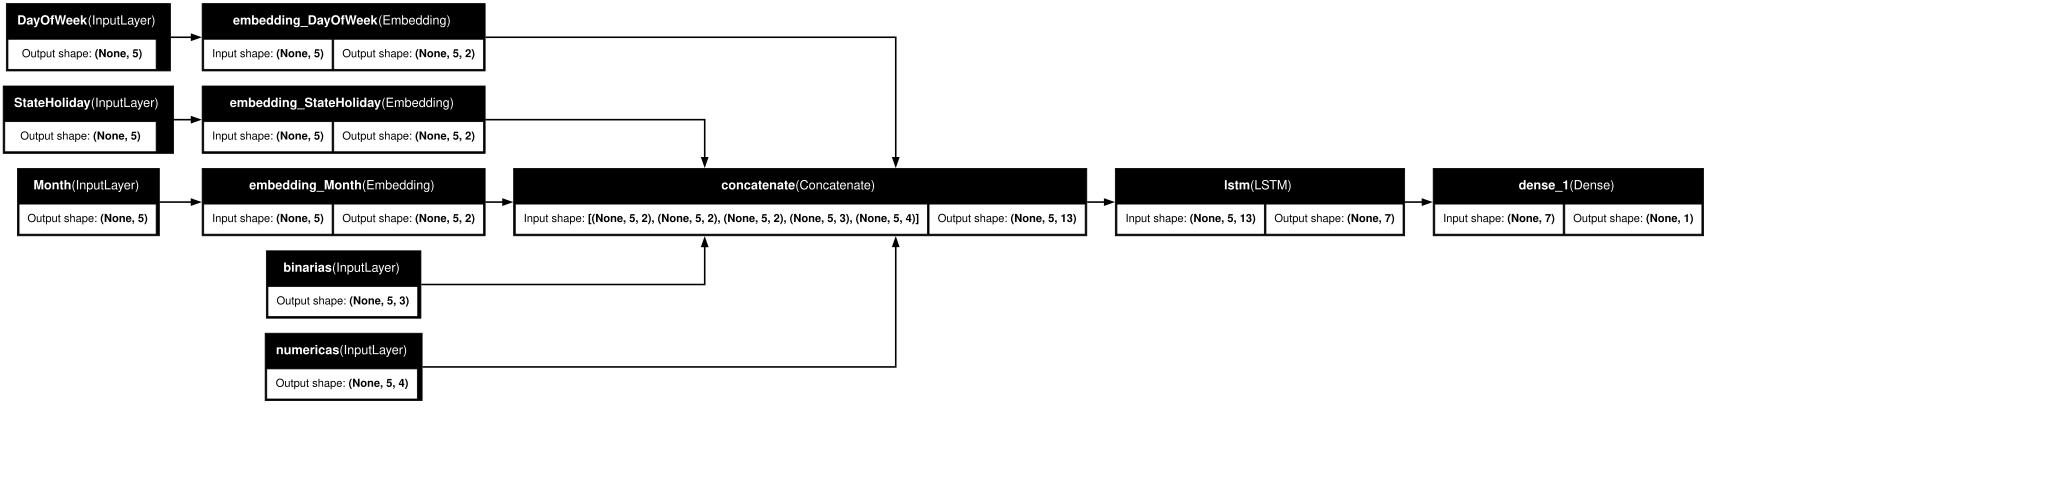

In [30]:
from IPython.display import SVG
from keras.utils import model_to_dot

# Ajustamos la resolución (dpi) y la orientación (rankdir='LR' para Izquierda a Derecha)
if COLAB:
    display(SVG(model_to_dot(model, show_shapes=True, dpi=60, rankdir='LR').create(prog="dot", format="svg")))
else:
    display(SVG(model_to_dot(model, show_shapes=True, dpi=60, rankdir='LR').create(prog="dot", format="svg")))

Finalmente, generamos los datos de entrenamiento y validación con la estructura esperada por las redes neuronales que vayamos a entrenar. Más concretamente, hay que filtrar las variables en función de las cinco fuentes de entrada de los modelos:

- Variable día de la semana `DayOfWeek`
- Variable estado de vacaciones `StateHoliday`
- Variable mes del año `Month`
- Variables categóricas y binarias `Open`, `Promo` y `SchoolHoliday`
- Variables numéricas `Sales_lag_1_day`, `Sales_lag_2_day`, `Sales_lag_1_week` y `Sales_lag_2_week`

In [31]:
# Dividimos los datos en función de las columnas para que cuadren con la arquitectura de la red neuronal
semana_train, semana_val = {}, {}
estado_vacaciones_train, estado_vacaciones_val = {}, {}
mes_train, mes_val = {}, {}
binarias_train, binarias_val = {}, {}
numericas_train, numericas_val = {}, {}

for tienda in tiendas:
    # Variables categoricas multiclase
    semana_train[tienda], semana_val[tienda] = X_train_final[tienda][:,:,0], X_val_final[tienda][:,:,0]
    estado_vacaciones_train[tienda], estado_vacaciones_val[tienda] = X_train_final[tienda][:,:,3], X_val_final[tienda][:,:,3]
    mes_train[tienda], mes_val[tienda] = X_train_final[tienda][:,:,5], X_val_final[tienda][:,:,5]

    # Variables binarias
    binarias_train[tienda], binarias_val[tienda] = X_train_final[tienda][:,:,[1,2,4]], X_val_final[tienda][:,:,[1,2,4]]

    # Variables numéricas
    numericas_train[tienda], numericas_val[tienda] = X_train_final[tienda][:,:,6:], X_val_final[tienda][:,:,6:]

In [32]:
Xs_tr, Xs_va = {}, {}

for tienda in tiendas:
    Xs_tr[tienda] = {"DayOfWeek": semana_train[tienda],
    "StateHoliday": estado_vacaciones_train[tienda],
    "Month": mes_train[tienda],
    "binarias": binarias_train[tienda],
    "numericas": numericas_train[tienda]}

    Xs_va[tienda] = {"DayOfWeek": semana_val[tienda],
    "StateHoliday": estado_vacaciones_val[tienda],
    "Month": mes_val[tienda],
    "binarias": binarias_val[tienda],
    "numericas": numericas_val[tienda]}

## <font color="#CA3532"> **6. Entrenamiento de los modelos para cada tienda**

In [33]:
import pickle

# Arquitectura para cada modelo de las tiendas individualizadas
dim_embedding = 2
data_window = 5

# Entradas de las variables categóricas multiclase que pasarán por embeddings
input0 = Input(shape=(data_window,), name="DayOfWeek") # 7 categorías
input1 = Input(shape=(data_window,), name="StateHoliday") # 4 categorías
input2 = Input(shape=(data_window,), name="Month") # 12 categorías

# Entradas de variables binarias
input3 = Input(shape=(data_window,3), name="binarias") 

# Entradas de variables numéricas estandarizadas
input4 = Input(shape=(data_window,4), name="numericas")

# Transformación en embeddings de las variables categóricas no binarias
embedding1 = Embedding(input_dim=8, output_dim=dim_embedding, input_length=data_window, name="embedding_DayOfWeek")(input0) # input_dim es 8 porque los días van [1,7]
embedding2 = Embedding(input_dim=4, output_dim=dim_embedding, input_length=data_window, name="embedding_StateHoliday")(input1)
embedding3 = Embedding(input_dim=13, output_dim=dim_embedding, input_length=data_window, name="embedding_Month")(input2) # input_dim es 8 porque los meses van [1,12]

Nos descargamos de las respectivas carpetas los modelos ya entrenados para cada tienda si no se quiere volver a ejecutar todo de nuevo.

- Standard Scaler para regresores
- Standard Scaler para variable respuesta
- Modelos funcionales

In [ ]:
# Cargamos los modelos standard scaler para la variable respuesta
#scaler_y_models = {}
#for tienda in tiendas:
#    with open('scaler_y/scaler_y_tienda_'+str(tienda)+'.pkl', 'rb') as f:
#        scaler_y_models[tienda] = pickle.load(f)

#scaler_models = {}
#for tienda in tiendas:
#    with open('scaler_X/scaler_x_tienda_'+str(tienda)+'.pkl', 'rb') as f:
#        scaler_models[tienda] = pickle.load(f)  

In [ ]:
# Nos descargamos los modelos funcionales ya entrenados
#models = {}
#for tienda in tiendas:
#   model = load_model('trained models/modelo_tienda_'+str(tienda)+'.keras')
#   models[tienda] = model

### <font color="#CA3532"> **6.1. Modelo tienda 1**

In [ ]:
# Cargar el modelo desde el disco
#model_1 = load_model('trained models/modelo_tienda_1.keras')

# Cargamos los modelos standard scaler
#scaler_y_models = {}
# with open('scaler_y/scaler_y_tienda_1.pkl', 'rb') as f:
#     scaler_y_models[1] = pickle.load(f)

In [34]:
x_1 = concatenate([embedding1, embedding2, embedding3, input3, input4])
x2_1 = LSTM(units=7, activation='relu')(x_1)
#x2_1 = Dropout(0.4)(x2_1)
x3_1 = Dense(units=5)(x2_1)
x4_1 = Dense(units=1)(x2_1)

model_1 = Model(inputs=[input0, input1, input2, input3, input4], outputs=x4_1)
model_1.compile(loss="mean_squared_error", optimizer=optimizers.Adam(learning_rate=0.001))

In [35]:
Xs_tr1, y_tr1 = Xs_tr[1], y_train_final[1]
Xs_va1, y_va1 = Xs_va[1], y_val_final[1]

history1 = model_1.fit(Xs_tr1, y_tr1, batch_size=32, epochs=300, validation_data=(Xs_va1, y_va1))

Epoch 1/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.9344 - val_loss: 0.5855
Epoch 2/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.8469 - val_loss: 0.5222
Epoch 3/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.7665 - val_loss: 0.4536
Epoch 4/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.6813 - val_loss: 0.3739
Epoch 5/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.5906 - val_loss: 0.2918
Epoch 6/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.5036 - val_loss: 0.2134
Epoch 7/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4322 - val_loss: 0.1623
Epoch 8/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3887 - val_loss: 0.1325
Epoch 9/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3655 - val_loss: 0.1178
Epoch 10/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3506 - val_loss: 0.1081
Epoch 11/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3343 - val_loss: 0.1013
Epoch 12/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/ste

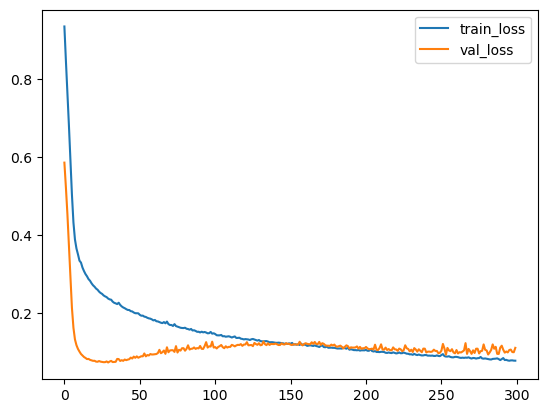

In [36]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.legend(['train_loss', 'val_loss'])

In [37]:
# Obtenemos las predicciones y deshacemos las transformaciones StandardScaler
y_pred_train_1 = scaler_y_models[1].inverse_transform(model_1.predict(Xs_tr1))
y_pred_val_1 = scaler_y_models[1].inverse_transform(model_1.predict(Xs_va1))

# Mostramos los R^2
print(f"R^2 Train = {R2_score(y_train[1][4:], y_pred_train_1)}")
print(f"R^2 Validación = {R2_score(y_val[1], y_pred_val_1)}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
R^2 Train = 0.9241984486579895
R^2 Validación = 0.8345630764961243


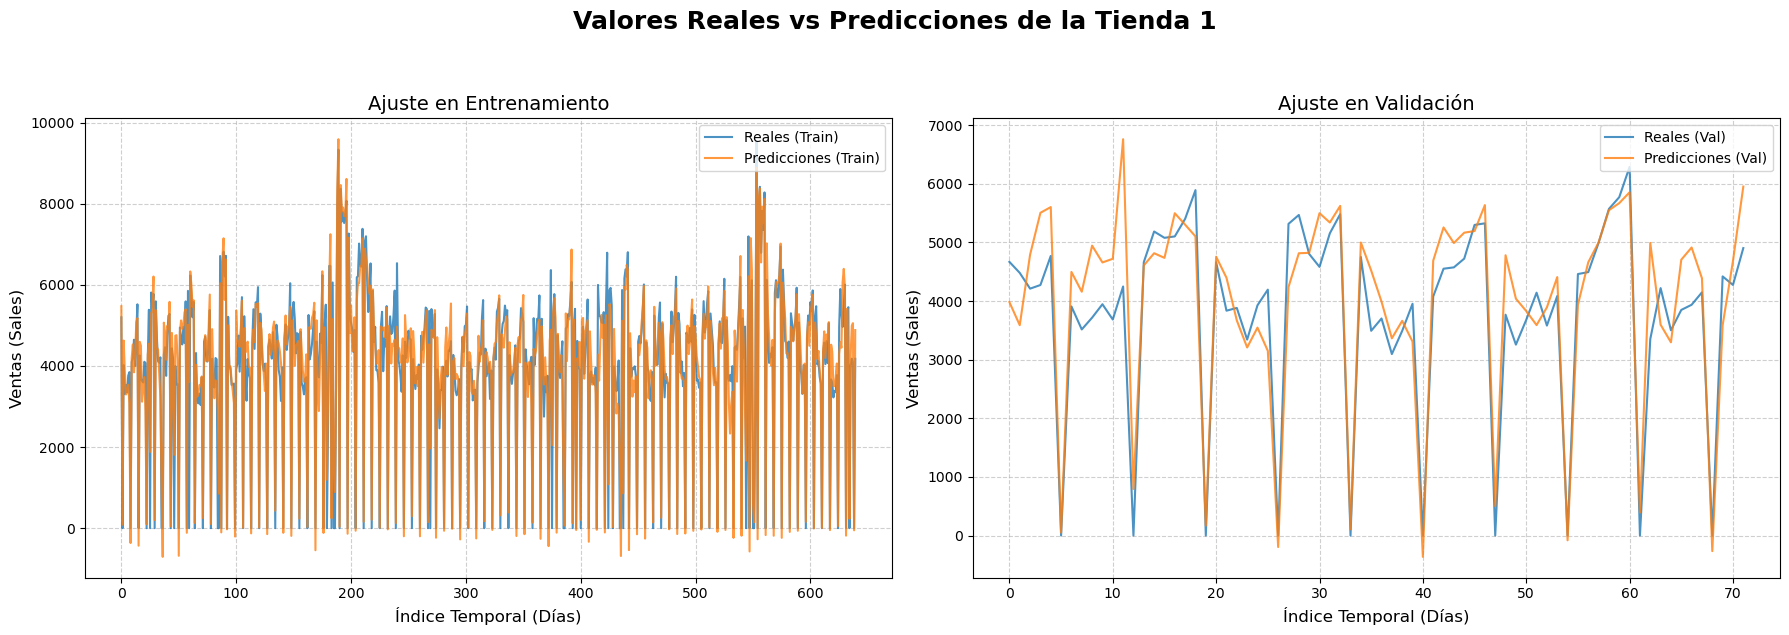

In [38]:
# Definimos el ID de la tienda actual para el título
tienda_id = 1

# 1. Configurar la figura y la matriz de subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# 2. Añadir el título general centrado
fig.suptitle(f'Valores Reales vs Predicciones de la Tienda {tienda_id}', fontsize=18, fontweight='bold', y=1.05)

# ---------------------------------------------------------
# Subplot Izquierdo: Datos de Entrenamiento
# ---------------------------------------------------------
# Usamos .values en los reales para ignorar el índice de Pandas y alinearlo con el array de NumPy
# Usamos .flatten() en las predicciones porque Keras devuelve una matriz (N, 1) y plt prefiere un vector (N,)
axes[0].plot(y_train[tienda_id][4:].values, label='Reales (Train)', color='#1f77b4', linewidth=1.5, alpha=0.8)
axes[0].plot(y_pred_train_1.flatten(), label='Predicciones (Train)', color='#ff7f0e', linewidth=1.5, alpha=0.8)

axes[0].set_title('Ajuste en Entrenamiento', fontsize=14)
axes[0].set_xlabel('Índice Temporal (Días)', fontsize=12)
axes[0].set_ylabel('Ventas (Sales)', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# ---------------------------------------------------------
# Subplot Derecho: Datos de Validación
# ---------------------------------------------------------
axes[1].plot(y_val[tienda_id].values, label='Reales (Val)', color='#1f77b4', linewidth=1.5, alpha=0.8)
axes[1].plot(y_pred_val_1.flatten(), label='Predicciones (Val)', color='#ff7f0e', linewidth=1.5, alpha=0.8)

axes[1].set_title('Ajuste en Validación', fontsize=14)
axes[1].set_xlabel('Índice Temporal (Días)', fontsize=12)
axes[1].set_ylabel('Ventas (Sales)', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

# 3. Ajustar el diseño para que no se superpongan elementos y mostrar
plt.tight_layout()
plt.show()

In [39]:
# Guardamos el modelo
model_1.save('trained models/modelo_tienda_1.keras')

# Guardamos el objeto standard scaler
with open('scaler_y/scaler_y_tienda_1.pkl', 'wb') as f:
    pickle.dump(scaler_y_models[1], f)

### <font color="#CA3532"> **6.2. Modelo tienda 2**

In [ ]:
# Cargar el modelo desde el disco
#model_2 = load_model('trained models/modelo_tienda_2.keras')

# Cargamos los modelos standard scaler
# with open('scaler_y/scaler_y_tienda_2.pkl', 'rb') as f:
#     scaler_y_models[2] = pickle.load(f)

In [40]:
x_2 = concatenate([embedding1, embedding2, embedding3, input3, input4])
x2_2 = LSTM(units=7, activation='relu')(x_2)
#x2_2 = Dropout(0.3)(x2_2)
x3_2 = Dense(units=5)(x2_2)
x4_2 = Dense(units=1)(x3_2)

model_2 = Model(inputs=[input0, input1, input2, input3, input4], outputs=x4_2)
model_2.compile(loss="mean_squared_error", optimizer=optimizers.Adam(learning_rate=0.001))

In [41]:
Xs_tr2, y_tr2 = Xs_tr[2], y_train_final[2]
Xs_va2, y_va2 = Xs_va[2], y_val_final[2]

history2 = model_2.fit(Xs_tr2, y_tr2, batch_size=32, epochs=300, validation_data=(Xs_va2, y_va2))

Epoch 1/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - loss: 0.8717 - val_loss: 0.5825
Epoch 2/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.7709 - val_loss: 0.4572
Epoch 3/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.6479 - val_loss: 0.3034
Epoch 4/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.5218 - val_loss: 0.1718
Epoch 5/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4226 - val_loss: 0.1066
Epoch 6/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.3659 - val_loss: 0.0843
Epoch 7/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3337 - val_loss: 0.0729
Epoch 8/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3029 - val_loss: 0.0660
Epoch 9/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2824 - val_loss: 0.0622
Epoch 10/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2663 - val_loss: 0.0573
Epoch 11/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.2560 - val_loss: 0.0555
Epoch 12/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/ste

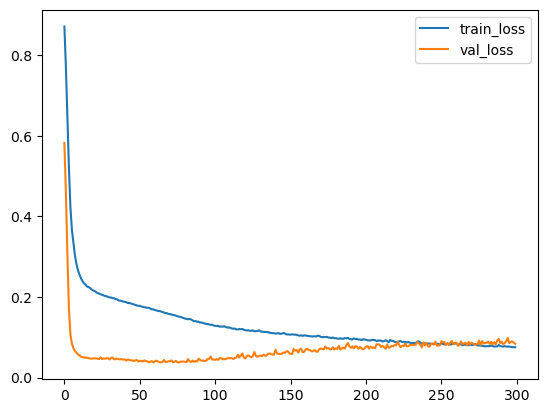

In [45]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.legend(['train_loss', 'val_loss'])

In [43]:
# Obtenemos las predicciones y deshacemos las transformaciones StandardScaler
y_pred_train_2 = scaler_y_models[2].inverse_transform(model_2.predict(Xs_tr2))
y_pred_val_2 = scaler_y_models[2].inverse_transform(model_2.predict(Xs_va2))

# Mostramos los R^2
print(f"R^2 Train = {R2_score(y_train[2][4:], y_pred_train_2)}")
print(f"R^2 Validación = {R2_score(y_val[2], y_pred_val_2)}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 327ms/step
R^2 Train = 0.9233314394950867
R^2 Validación = 0.8931598663330078


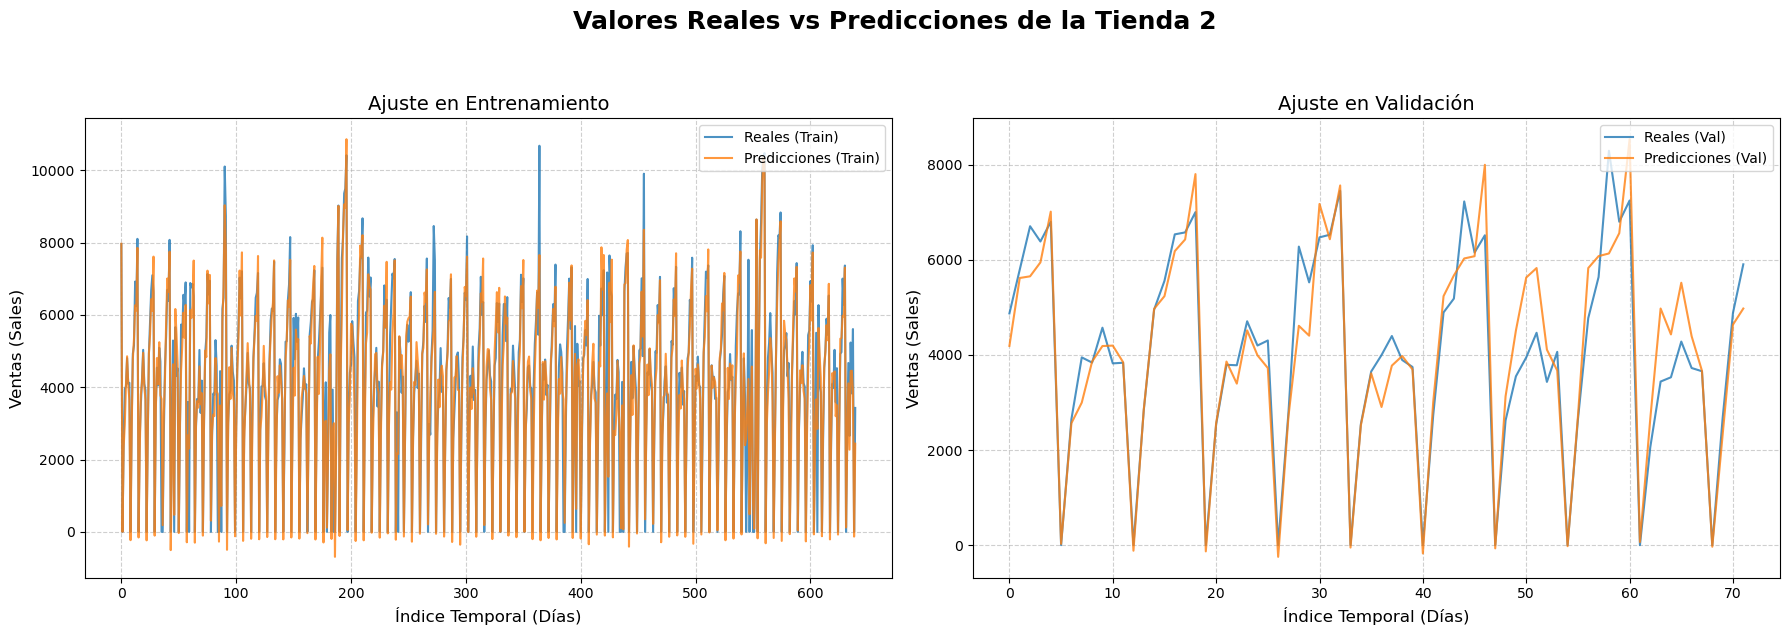

In [44]:
# Definimos el ID de la tienda actual para el título
tienda_id = 2

# 1. Configurar la figura y la matriz de subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# 2. Añadir el título general centrado
fig.suptitle(f'Valores Reales vs Predicciones de la Tienda {tienda_id}', fontsize=18, fontweight='bold', y=1.05)

# ---------------------------------------------------------
# Subplot Izquierdo: Datos de Entrenamiento
# ---------------------------------------------------------
# Usamos .values en los reales para ignorar el índice de Pandas y alinearlo con el array de NumPy
# Usamos .flatten() en las predicciones porque Keras devuelve una matriz (N, 1) y plt prefiere un vector (N,)
axes[0].plot(y_train[tienda_id][4:].values, label='Reales (Train)', color='#1f77b4', linewidth=1.5, alpha=0.8)
axes[0].plot(y_pred_train_2.flatten(), label='Predicciones (Train)', color='#ff7f0e', linewidth=1.5, alpha=0.8)

axes[0].set_title('Ajuste en Entrenamiento', fontsize=14)
axes[0].set_xlabel('Índice Temporal (Días)', fontsize=12)
axes[0].set_ylabel('Ventas (Sales)', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# ---------------------------------------------------------
# Subplot Derecho: Datos de Validación
# ---------------------------------------------------------
axes[1].plot(y_val[tienda_id].values, label='Reales (Val)', color='#1f77b4', linewidth=1.5, alpha=0.8)
axes[1].plot(y_pred_val_2.flatten(), label='Predicciones (Val)', color='#ff7f0e', linewidth=1.5, alpha=0.8)

axes[1].set_title('Ajuste en Validación', fontsize=14)
axes[1].set_xlabel('Índice Temporal (Días)', fontsize=12)
axes[1].set_ylabel('Ventas (Sales)', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

# 3. Ajustar el diseño para que no se superpongan elementos y mostrar
plt.tight_layout()
plt.show()

In [46]:
# Guardamos el modelo
model_2.save('trained models/modelo_tienda_2.keras')

# Guardamos el objeto standard scaler
with open('scaler_y/scaler_y_tienda_2.pkl', 'wb') as f:
    pickle.dump(scaler_y_models[2], f)

### <font color="#CA3532"> **6.3. Modelo tienda 3**

In [ ]:
# Cargar el modelo desde el disco
#model_3 = load_model('trained models/modelo_tienda_3.keras')

# Cargamos los modelos standard scaler
# with open('scaler_y/scaler_y_tienda_3.pkl', 'rb') as f:
#     scaler_y_models[3] = pickle.load(f)

In [47]:
x_3 = concatenate([embedding1, embedding2, embedding3, input3, input4])
x2_3 = LSTM(units=7, activation='relu')(x_3)
#x2_3 = Dropout(0.4)(x2_3)
x3_3 = Dense(units=5)(x2_3)
x4_3 = Dense(units=1)(x3_3)

model_3 = Model(inputs=[input0, input1, input2, input3, input4], outputs=x4_3)
model_3.compile(loss="mean_squared_error", optimizer=optimizers.Adam(learning_rate=0.001))

In [48]:
Xs_tr3, y_tr3 = Xs_tr[3], y_train_final[3]
Xs_va3, y_va3 = Xs_va[3], y_val_final[3]

history3 = model_3.fit(Xs_tr3, y_tr3, batch_size=32, epochs=300, validation_data=(Xs_va3, y_va3))

Epoch 1/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 64ms/step - loss: 1.0016 - val_loss: 0.8139
Epoch 2/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.9399 - val_loss: 0.7499
Epoch 3/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.8721 - val_loss: 0.6401
Epoch 4/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7641 - val_loss: 0.4863
Epoch 5/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.6149 - val_loss: 0.2985
Epoch 6/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4693 - val_loss: 0.1708
Epoch 7/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.3847 - val_loss: 0.1294
Epoch 8/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3506 - val_loss: 0.1231
Epoch 9/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.3274 - val_loss: 0.1245
Epoch 10/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3124 - val_loss: 0.1220
Epoch 11/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3025 - val_loss: 0.1144
Epoch 12/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/ste

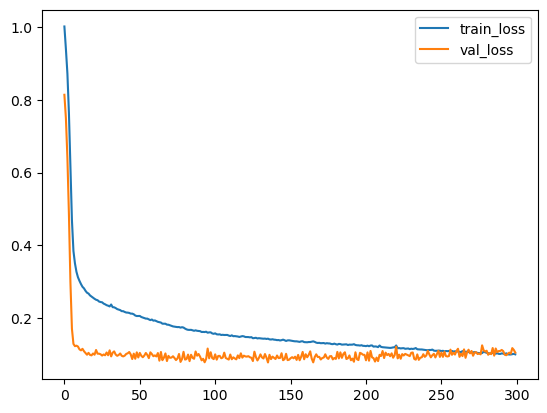

In [49]:
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
plt.legend(['train_loss', 'val_loss'])

In [50]:
# Obtenemos las predicciones y deshacemos las transformaciones StandardScaler
y_pred_train_3 = scaler_y_models[3].inverse_transform(model_3.predict(Xs_tr3))
y_pred_val_3 = scaler_y_models[3].inverse_transform(model_3.predict(Xs_va3))

# Mostramos los R^2
print(f"R^2 Train = {R2_score(y_train[3][4:], y_pred_train_3)}")
print(f"R^2 Validación = {R2_score(y_val[3], y_pred_val_3)}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 265ms/step
R^2 Train = 0.9020736813545227
R^2 Validación = 0.8764547109603882


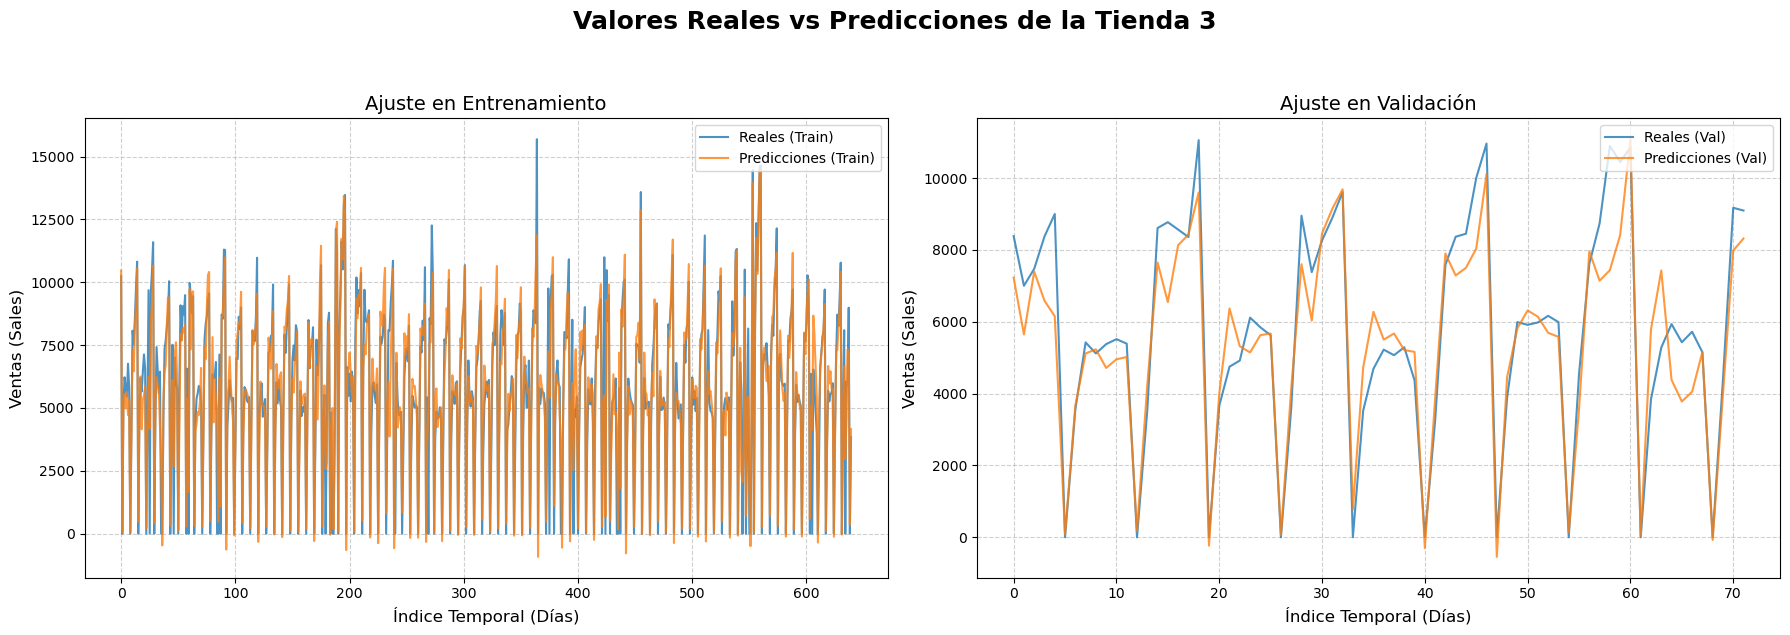

In [51]:
# Definimos el ID de la tienda actual para el título
tienda_id = 3

# 1. Configurar la figura y la matriz de subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# 2. Añadir el título general centrado
fig.suptitle(f'Valores Reales vs Predicciones de la Tienda {tienda_id}', fontsize=18, fontweight='bold', y=1.05)

# ---------------------------------------------------------
# Subplot Izquierdo: Datos de Entrenamiento
# ---------------------------------------------------------
# Usamos .values en los reales para ignorar el índice de Pandas y alinearlo con el array de NumPy
# Usamos .flatten() en las predicciones porque Keras devuelve una matriz (N, 1) y plt prefiere un vector (N,)
axes[0].plot(y_train[tienda_id][4:].values, label='Reales (Train)', color='#1f77b4', linewidth=1.5, alpha=0.8)
axes[0].plot(y_pred_train_3.flatten(), label='Predicciones (Train)', color='#ff7f0e', linewidth=1.5, alpha=0.8)

axes[0].set_title('Ajuste en Entrenamiento', fontsize=14)
axes[0].set_xlabel('Índice Temporal (Días)', fontsize=12)
axes[0].set_ylabel('Ventas (Sales)', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# ---------------------------------------------------------
# Subplot Derecho: Datos de Validación
# ---------------------------------------------------------
axes[1].plot(y_val[tienda_id].values, label='Reales (Val)', color='#1f77b4', linewidth=1.5, alpha=0.8)
axes[1].plot(y_pred_val_3.flatten(), label='Predicciones (Val)', color='#ff7f0e', linewidth=1.5, alpha=0.8)

axes[1].set_title('Ajuste en Validación', fontsize=14)
axes[1].set_xlabel('Índice Temporal (Días)', fontsize=12)
axes[1].set_ylabel('Ventas (Sales)', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

# 3. Ajustar el diseño para que no se superpongan elementos y mostrar
plt.tight_layout()
plt.show()

In [52]:
# Guardamos el modelo
model_3.save('trained models/modelo_tienda_3.keras')

# Guardamos el objeto standard scaler
with open('scaler_y/scaler_y_tienda_3.pkl', 'wb') as f:
    pickle.dump(scaler_y_models[3], f)

### <font color="#CA3532"> **6.4. Modelo tienda 4**

In [ ]:
# Cargar el modelo desde el disco
#model_4 = load_model('trained models/modelo_tienda_4.keras')

# Cargamos los modelos standard scaler
# with open('scaler_y/scaler_y_tienda_4.pkl', 'rb') as f:
#     scaler_y_models[4] = pickle.load(f)

In [63]:
x_4 = concatenate([embedding1, embedding2, embedding3, input3, input4])
x2_4 = LSTM(units=7, activation='relu')(x_4)
#x2_4 = Dropout(0.3)(x2_4)
x3_4 = Dense(units=7)(x2_4)
x4_4 = Dense(units=1)(x3_4)

model_4 = Model(inputs=[input0, input1, input2, input3, input4], outputs=x4_4)
model_4.compile(loss="mean_squared_error", optimizer=optimizers.Adam(learning_rate=0.001))

In [64]:
Xs_tr4, y_tr4 = Xs_tr[4], y_train_final[4]
Xs_va4, y_va4 = Xs_va[4], y_val_final[4]

history4 = model_4.fit(Xs_tr4, y_tr4, batch_size=32, epochs=300, validation_data=(Xs_va4, y_va4))

Epoch 1/300


20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - loss: 1.1118 - val_loss: 0.7490
Epoch 2/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0296 - val_loss: 0.7428
Epoch 3/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.9857 - val_loss: 0.7194
Epoch 4/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9260 - val_loss: 0.6792
Epoch 5/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7843 - val_loss: 0.5278
Epoch 6/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5578 - val_loss: 0.3119
Epoch 7/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4248 - val_loss: 0.2178
Epoch 8/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3814 - val_loss: 0.1811
Epoch 9/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3583 - val_loss: 0.1648
Epoch 10/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3434 - val_loss: 0.1510
Epoch 11/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3315 - val_loss: 0.1448
Epoch 12/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3

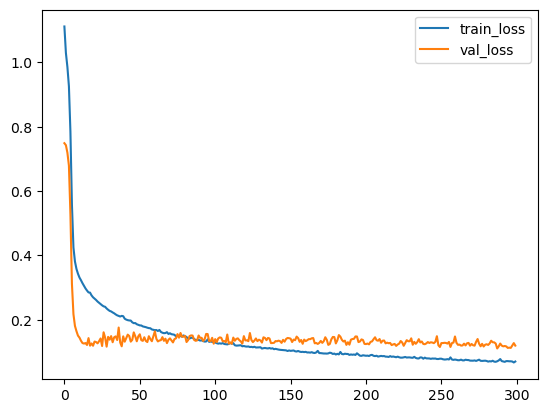

In [65]:
plt.plot(history4.history['loss'])
plt.plot(history4.history['val_loss'])
plt.legend(['train_loss', 'val_loss'])

In [66]:
# Obtenemos las predicciones y deshacemos las transformaciones StandardScaler
y_pred_train_4 = scaler_y_models[4].inverse_transform(model_4.predict(Xs_tr4))
y_pred_val_4 = scaler_y_models[4].inverse_transform(model_4.predict(Xs_va4))

# Mostramos los R^2
print(f"R^2 Train = {R2_score(y_train[4][4:], y_pred_train_4)}")
print(f"R^2 Validación = {R2_score(y_val[4], y_pred_val_4)}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step 
R^2 Train = 0.933748722076416
R^2 Validación = 0.8201725482940674


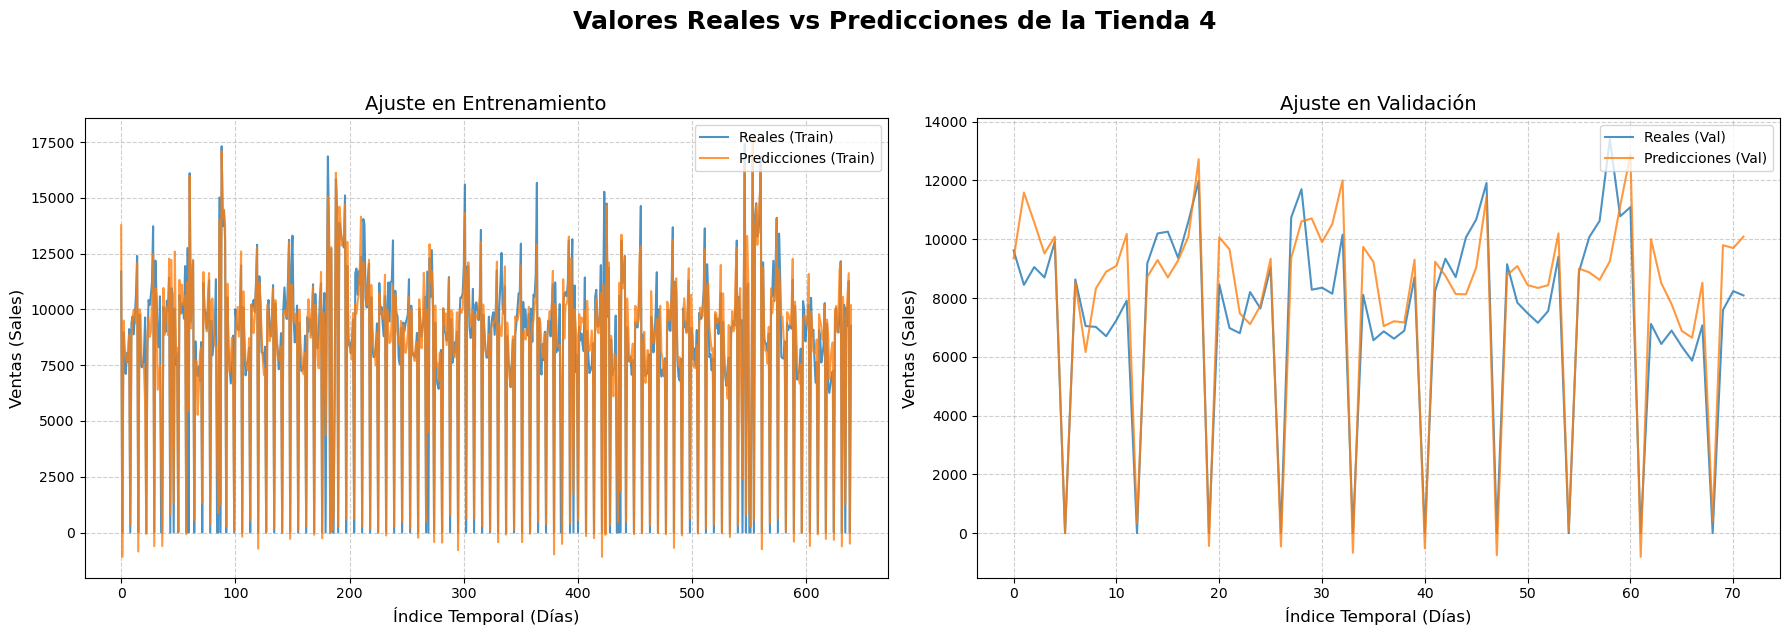

In [67]:
# Definimos el ID de la tienda actual para el título
tienda_id = 4

# 1. Configurar la figura y la matriz de subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# 2. Añadir el título general centrado
fig.suptitle(f'Valores Reales vs Predicciones de la Tienda {tienda_id}', fontsize=18, fontweight='bold', y=1.05)

# ---------------------------------------------------------
# Subplot Izquierdo: Datos de Entrenamiento
# ---------------------------------------------------------
# Usamos .values en los reales para ignorar el índice de Pandas y alinearlo con el array de NumPy
# Usamos .flatten() en las predicciones porque Keras devuelve una matriz (N, 1) y plt prefiere un vector (N,)
axes[0].plot(y_train[tienda_id][4:].values, label='Reales (Train)', color='#1f77b4', linewidth=1.5, alpha=0.8)
axes[0].plot(y_pred_train_4.flatten(), label='Predicciones (Train)', color='#ff7f0e', linewidth=1.5, alpha=0.8)

axes[0].set_title('Ajuste en Entrenamiento', fontsize=14)
axes[0].set_xlabel('Índice Temporal (Días)', fontsize=12)
axes[0].set_ylabel('Ventas (Sales)', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# ---------------------------------------------------------
# Subplot Derecho: Datos de Validación
# ---------------------------------------------------------
axes[1].plot(y_val[tienda_id].values, label='Reales (Val)', color='#1f77b4', linewidth=1.5, alpha=0.8)
axes[1].plot(y_pred_val_4.flatten(), label='Predicciones (Val)', color='#ff7f0e', linewidth=1.5, alpha=0.8)

axes[1].set_title('Ajuste en Validación', fontsize=14)
axes[1].set_xlabel('Índice Temporal (Días)', fontsize=12)
axes[1].set_ylabel('Ventas (Sales)', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

# 3. Ajustar el diseño para que no se superpongan elementos y mostrar
plt.tight_layout()
plt.show()

In [68]:
# Guardamos el modelo
model_4.save('trained models/modelo_tienda_4.keras')

# Guardamos el objeto standard scaler
with open('scaler_y/scaler_y_tienda_4.pkl', 'wb') as f:
    pickle.dump(scaler_y_models[4], f)

### <font color="#CA3532"> **6.5. Modelo tienda 5**

In [ ]:
# Cargar el modelo desde el disco
#model_5 = load_model('trained models/modelo_tienda_5.keras')

# Cargamos los modelos standard scaler
# with open('scaler_y/scaler_y_tienda_5.pkl', 'rb') as f:
#     scaler_y_models[5] = pickle.load(f)

In [69]:
x_5 = concatenate([embedding1, embedding2, embedding3, input3, input4])
x2_5 = LSTM(units=7, activation='relu')(x_5)
#x2_5 = Dropout(0.3)(x2_5)
x3_5 = Dense(units=5)(x2_5)
x4_5 = Dense(units=1)(x3_5)

model_5 = Model(inputs=[input0, input1, input2, input3, input4], outputs=x4_5)
model_5.compile(loss="mean_squared_error", optimizer=optimizers.Adam(learning_rate=0.001))

In [70]:
Xs_tr5, y_tr5 = Xs_tr[5], y_train_final[5]
Xs_va5, y_va5 = Xs_va[5], y_val_final[5]

history5 = model_5.fit(Xs_tr5, y_tr5, batch_size=32, epochs=300, validation_data=(Xs_va5, y_va5))

Epoch 1/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 108ms/step - loss: 0.8504 - val_loss: 0.6866
Epoch 2/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.7386 - val_loss: 0.5868
Epoch 3/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6452 - val_loss: 0.4932
Epoch 4/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.5672 - val_loss: 0.4128
Epoch 5/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.5125 - val_loss: 0.3488
Epoch 6/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4691 - val_loss: 0.3079
Epoch 7/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4362 - val_loss: 0.2590
Epoch 8/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4105 - val_loss: 0.2339
Epoch 9/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3831 - val_loss: 0.2034
Epoch 10/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3608 - val_loss: 0.1734
Epoch 11/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3377 - val_loss: 0.1462
Epoch 12/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/st

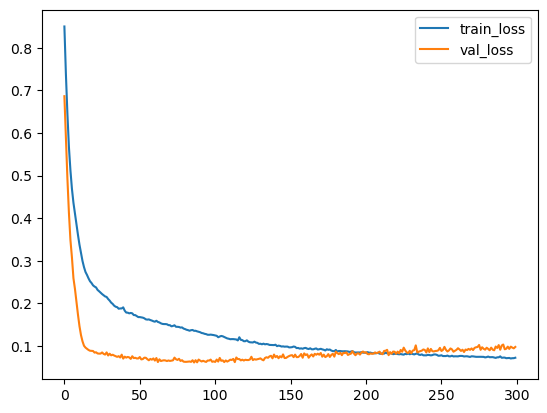

In [71]:
plt.plot(history5.history['loss'])
plt.plot(history5.history['val_loss'])
plt.legend(['train_loss', 'val_loss'])

In [72]:
# Obtenemos las predicciones y deshacemos las transformaciones StandardScaler
y_pred_train_5 = scaler_y_models[5].inverse_transform(model_5.predict(Xs_tr5))
y_pred_val_5 = scaler_y_models[5].inverse_transform(model_5.predict(Xs_va5))

# Mostramos los R^2
print(f"R^2 Train = {R2_score(y_train[5][4:], y_pred_train_5)}")
print(f"R^2 Validación = {R2_score(y_val[5], y_pred_val_5)}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 451ms/step
R^2 Train = 0.9307383298873901
R^2 Validación = 0.8880807161331177


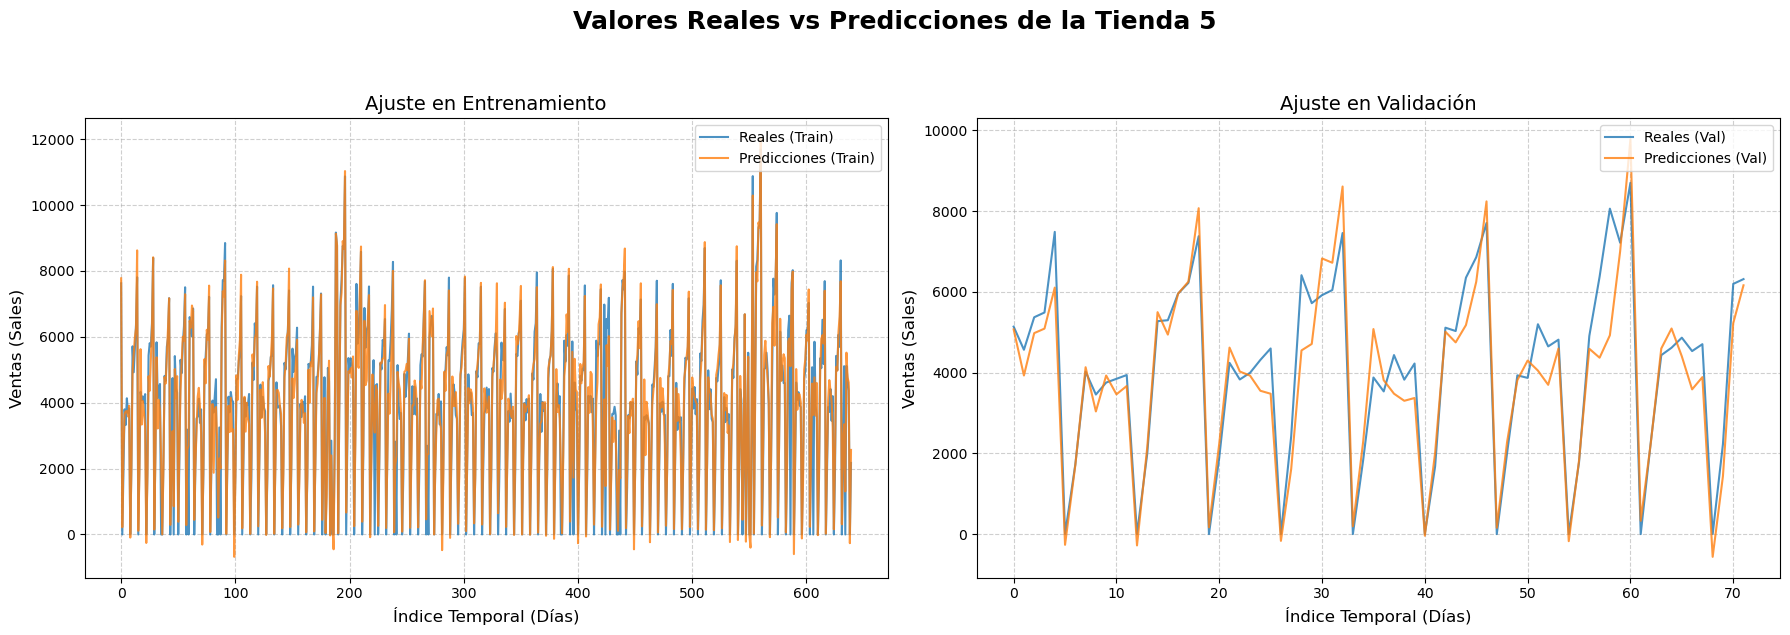

In [73]:
# Definimos el ID de la tienda actual para el título
tienda_id = 5

# 1. Configurar la figura y la matriz de subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# 2. Añadir el título general centrado
fig.suptitle(f'Valores Reales vs Predicciones de la Tienda {tienda_id}', fontsize=18, fontweight='bold', y=1.05)

# ---------------------------------------------------------
# Subplot Izquierdo: Datos de Entrenamiento
# ---------------------------------------------------------
# Usamos .values en los reales para ignorar el índice de Pandas y alinearlo con el array de NumPy
# Usamos .flatten() en las predicciones porque Keras devuelve una matriz (N, 1) y plt prefiere un vector (N,)
axes[0].plot(y_train[tienda_id][4:].values, label='Reales (Train)', color='#1f77b4', linewidth=1.5, alpha=0.8)
axes[0].plot(y_pred_train_5.flatten(), label='Predicciones (Train)', color='#ff7f0e', linewidth=1.5, alpha=0.8)

axes[0].set_title('Ajuste en Entrenamiento', fontsize=14)
axes[0].set_xlabel('Índice Temporal (Días)', fontsize=12)
axes[0].set_ylabel('Ventas (Sales)', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# ---------------------------------------------------------
# Subplot Derecho: Datos de Validación
# ---------------------------------------------------------
axes[1].plot(y_val[tienda_id].values, label='Reales (Val)', color='#1f77b4', linewidth=1.5, alpha=0.8)
axes[1].plot(y_pred_val_5.flatten(), label='Predicciones (Val)', color='#ff7f0e', linewidth=1.5, alpha=0.8)

axes[1].set_title('Ajuste en Validación', fontsize=14)
axes[1].set_xlabel('Índice Temporal (Días)', fontsize=12)
axes[1].set_ylabel('Ventas (Sales)', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

# 3. Ajustar el diseño para que no se superpongan elementos y mostrar
plt.tight_layout()
plt.show()

In [74]:
# Guardamos el modelo
model_5.save('trained models/modelo_tienda_5.keras')

# Guardamos el objeto standard scaler
with open('scaler_y/scaler_y_tienda_5.pkl', 'wb') as f:
    pickle.dump(scaler_y_models[5], f)

### <font color="#CA3532"> **6.6. Modelo tienda 562**

In [ ]:
# Cargar el modelo desde el disco
#model_562 = load_model('trained models/modelo_tienda_562.keras')

# Cargamos los modelos standard scaler
# with open('scaler_y/scaler_y_tienda_562.pkl', 'rb') as f:
#     scaler_y_models[562] = pickle.load(f)

In [75]:
x_562 = concatenate([embedding1, embedding2, embedding3, input3, input4])
x2_562 = LSTM(units=7, activation='relu')(x_562)
#x2_562 = Dropout(0.4)(x2_562)
x3_562 = Dense(units=5)(x2_562)
#x3_562 = Dropout(0.2)(x3_562)
x4_562 = Dense(units=1)(x3_562)

model_562 = Model(inputs=[input0, input1, input2, input3, input4], outputs=x4_562)
model_562.compile(loss="mean_squared_error", optimizer=optimizers.Adam(learning_rate=0.0005))

In [76]:
Xs_tr562, y_tr562 = Xs_tr[562], y_train_final[562]
Xs_va562, y_va562 = Xs_va[562], y_val_final[562]

history562 = model_562.fit(Xs_tr562, y_tr562, batch_size=32, epochs=300, validation_data=(Xs_va562, y_va562))

Epoch 1/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - loss: 1.1258 - val_loss: 1.0126
Epoch 2/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0532 - val_loss: 0.9878
Epoch 3/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.0071 - val_loss: 0.9548
Epoch 4/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.9723 - val_loss: 0.9247
Epoch 5/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.9431 - val_loss: 0.9165
Epoch 6/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.9147 - val_loss: 0.8837
Epoch 7/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.8856 - val_loss: 0.8540
Epoch 8/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.8554 - val_loss: 0.8263
Epoch 9/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.8203 - val_loss: 0.8053
Epoch 10/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7878 - val_loss: 0.7289
Epoch 11/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.7492 - val_loss: 0.7052
Epoch 12/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/ste

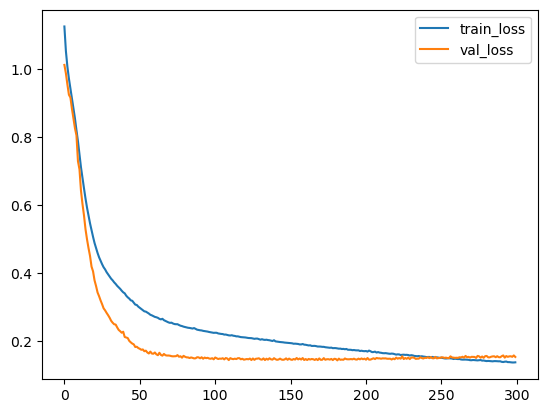

In [77]:
plt.plot(history562.history['loss'])
plt.plot(history562.history['val_loss'])
plt.legend(['train_loss', 'val_loss'])

In [78]:
# Obtenemos las predicciones y deshacemos las transformaciones StandardScaler
y_pred_train_562 = scaler_y_models[562].inverse_transform(model_562.predict(Xs_tr562))
y_pred_val_562 = scaler_y_models[562].inverse_transform(model_562.predict(Xs_va562))

# Mostramos los R^2
print(f"R^2 Train = {R2_score(y_train[562][4:], y_pred_train_562)}")
print(f"R^2 Validación = {R2_score(y_val[562], y_pred_val_562)}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 347ms/step
R^2 Train = 0.8649195432662964
R^2 Validación = 0.784947395324707


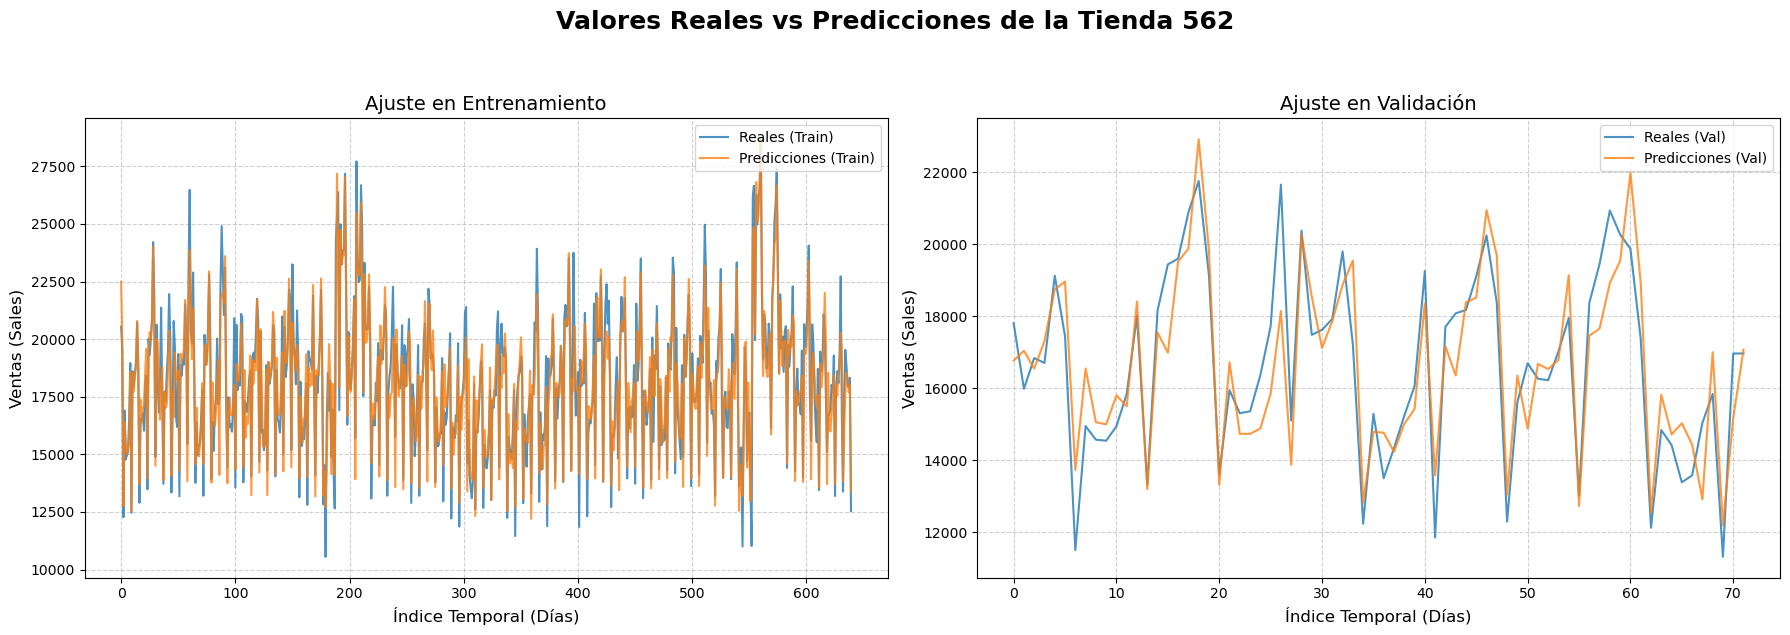

In [79]:
# Definimos el ID de la tienda actual para el título
tienda_id = 562

# 1. Configurar la figura y la matriz de subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# 2. Añadir el título general centrado
fig.suptitle(f'Valores Reales vs Predicciones de la Tienda {tienda_id}', fontsize=18, fontweight='bold', y=1.05)

# ---------------------------------------------------------
# Subplot Izquierdo: Datos de Entrenamiento
# ---------------------------------------------------------
# Usamos .values en los reales para ignorar el índice de Pandas y alinearlo con el array de NumPy
# Usamos .flatten() en las predicciones porque Keras devuelve una matriz (N, 1) y plt prefiere un vector (N,)
axes[0].plot(y_train[tienda_id][4:].values, label='Reales (Train)', color='#1f77b4', linewidth=1.5, alpha=0.8)
axes[0].plot(y_pred_train_562.flatten(), label='Predicciones (Train)', color='#ff7f0e', linewidth=1.5, alpha=0.8)

axes[0].set_title('Ajuste en Entrenamiento', fontsize=14)
axes[0].set_xlabel('Índice Temporal (Días)', fontsize=12)
axes[0].set_ylabel('Ventas (Sales)', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# ---------------------------------------------------------
# Subplot Derecho: Datos de Validación
# ---------------------------------------------------------
axes[1].plot(y_val[tienda_id].values, label='Reales (Val)', color='#1f77b4', linewidth=1.5, alpha=0.8)
axes[1].plot(y_pred_val_562.flatten(), label='Predicciones (Val)', color='#ff7f0e', linewidth=1.5, alpha=0.8)

axes[1].set_title('Ajuste en Validación', fontsize=14)
axes[1].set_xlabel('Índice Temporal (Días)', fontsize=12)
axes[1].set_ylabel('Ventas (Sales)', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

# 3. Ajustar el diseño para que no se superpongan elementos y mostrar
plt.tight_layout()
plt.show()

In [80]:
# Guardamos el modelo
model_562.save('trained models/modelo_tienda_562.keras')

# Guardamos el objeto standard scaler
with open('scaler_y/scaler_y_tienda_562.pkl', 'wb') as f:
    pickle.dump(scaler_y_models[562], f)

### <font color="#CA3532"> **6.7. Modelo tienda 682**

In [ ]:
# Cargar el modelo desde el disco
#model_682 = load_model('trained models/modelo_tienda_682.keras')

# Cargamos los modelos standard scaler
# with open('scaler_y/scaler_y_tienda_682.pkl', 'rb') as f:
#     scaler_y_models[682] = pickle.load(f)

In [81]:
x_682 = concatenate([embedding1, embedding2, embedding3, input3, input4])
x2_682 = LSTM(units=7, activation='relu')(x_682)
#x2_682 = Dropout(0.4)(x2_682)
x3_682 = Dense(units=5)(x2_682)
x4_682 = Dense(units=1)(x3_682)

model_682 = Model(inputs=[input0, input1, input2, input3, input4], outputs=x4_682)
model_682.compile(loss="mean_squared_error", optimizer=optimizers.Adam(learning_rate=0.0005))

In [82]:
Xs_tr682, y_tr682 = Xs_tr[682], y_train_final[682]
Xs_va682, y_va682 = Xs_va[682], y_val_final[682]

history682 = model_682.fit(Xs_tr682, y_tr682, batch_size=32, epochs=300, validation_data=(Xs_va682, y_va682))

Epoch 1/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - loss: 1.0444 - val_loss: 0.7900
Epoch 2/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.9709 - val_loss: 0.7723
Epoch 3/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.9284 - val_loss: 0.7528
Epoch 4/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.8842 - val_loss: 0.7200
Epoch 5/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.8268 - val_loss: 0.6611
Epoch 6/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.7484 - val_loss: 0.5775
Epoch 7/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6459 - val_loss: 0.4760
Epoch 8/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.5427 - val_loss: 0.3694
Epoch 9/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.4596 - val_loss: 0.2965
Epoch 10/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.4202 - val_loss: 0.2577
Epoch 11/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.3983 - val_loss: 0.2376
Epoch 12/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/st

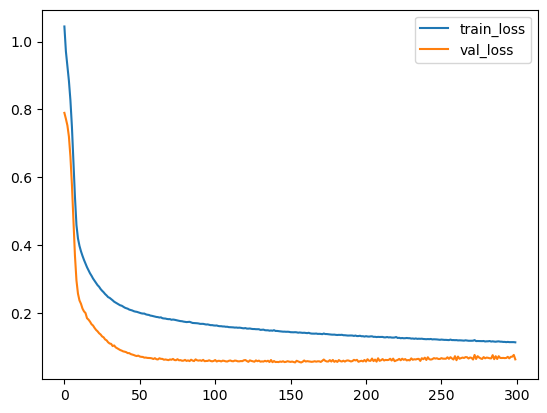

In [83]:
plt.plot(history682.history['loss'])
plt.plot(history682.history['val_loss'])
plt.legend(['train_loss', 'val_loss'])

In [84]:
# Obtenemos las predicciones y deshacemos las transformaciones StandardScaler
y_pred_train_682 = scaler_y_models[682].inverse_transform(model_682.predict(Xs_tr682))
y_pred_val_682 = scaler_y_models[682].inverse_transform(model_682.predict(Xs_va682))

# Mostramos los R^2
print(f"R^2 Train = {R2_score(y_train[682][4:], y_pred_train_682)}")
print(f"R^2 Validación = {R2_score(y_val[682], y_pred_val_682)}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 376ms/step
R^2 Train = 0.884688675403595
R^2 Validación = 0.9142224788665771


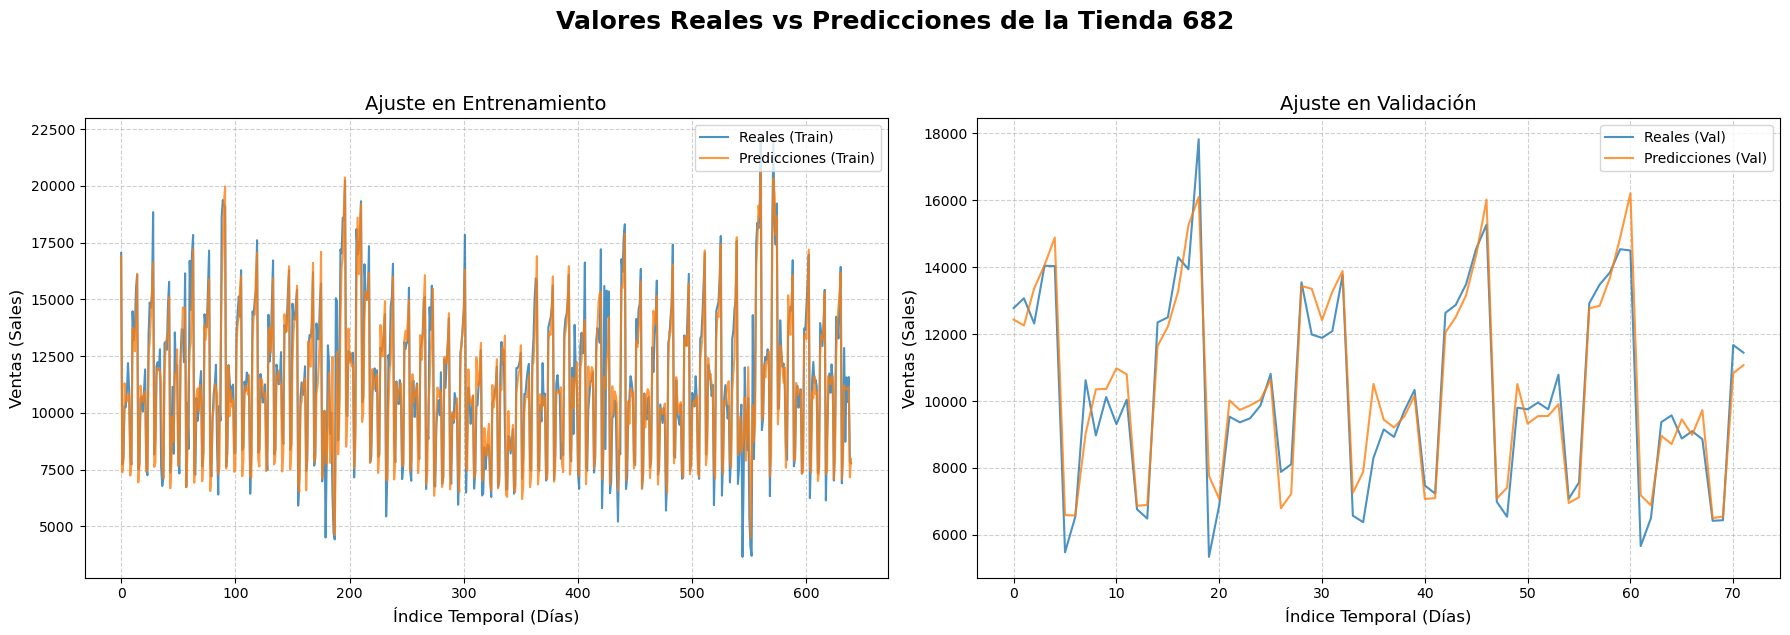

In [85]:
# Definimos el ID de la tienda actual para el título
tienda_id = 682

# 1. Configurar la figura y la matriz de subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# 2. Añadir el título general centrado
fig.suptitle(f'Valores Reales vs Predicciones de la Tienda {tienda_id}', fontsize=18, fontweight='bold', y=1.05)

# ---------------------------------------------------------
# Subplot Izquierdo: Datos de Entrenamiento
# ---------------------------------------------------------
# Usamos .values en los reales para ignorar el índice de Pandas y alinearlo con el array de NumPy
# Usamos .flatten() en las predicciones porque Keras devuelve una matriz (N, 1) y plt prefiere un vector (N,)
axes[0].plot(y_train[tienda_id][4:].values, label='Reales (Train)', color='#1f77b4', linewidth=1.5, alpha=0.8)
axes[0].plot(y_pred_train_682.flatten(), label='Predicciones (Train)', color='#ff7f0e', linewidth=1.5, alpha=0.8)

axes[0].set_title('Ajuste en Entrenamiento', fontsize=14)
axes[0].set_xlabel('Índice Temporal (Días)', fontsize=12)
axes[0].set_ylabel('Ventas (Sales)', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# ---------------------------------------------------------
# Subplot Derecho: Datos de Validación
# ---------------------------------------------------------
axes[1].plot(y_val[tienda_id].values, label='Reales (Val)', color='#1f77b4', linewidth=1.5, alpha=0.8)
axes[1].plot(y_pred_val_682.flatten(), label='Predicciones (Val)', color='#ff7f0e', linewidth=1.5, alpha=0.8)

axes[1].set_title('Ajuste en Validación', fontsize=14)
axes[1].set_xlabel('Índice Temporal (Días)', fontsize=12)
axes[1].set_ylabel('Ventas (Sales)', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

# 3. Ajustar el diseño para que no se superpongan elementos y mostrar
plt.tight_layout()
plt.show()

In [86]:
# Guardamos el modelo
model_682.save('trained models/modelo_tienda_682.keras')

# Guardamos el objeto standard scaler
with open('scaler_y/scaler_y_tienda_682.pkl', 'wb') as f:
    pickle.dump(scaler_y_models[682], f)

### <font color="#CA3532"> **6.8. Modelo tienda 733**

In [ ]:
# Cargar el modelo desde el disco
#model_733 = load_model('trained models/modelo_tienda_733.keras')

# Cargamos los modelos standard scaler
# with open('scaler_y/scaler_y_tienda_733.pkl', 'rb') as f:
#     scaler_y_models[733] = pickle.load(f)

In [102]:
x_733 = concatenate([embedding1, embedding2, embedding3, input3, input4])
x2_733 = LSTM(units=10, activation='tanh')(x_733)
x2_733 = Dropout(0.2)(x2_733)
x3_733 = Dense(units=7)(x2_733)
#x3_733 = Dropout(0.2)(x3_733)
x4_733 = Dense(units=1)(x3_733)

model_733 = Model(inputs=[input0, input1, input2, input3, input4], outputs=x4_733)
model_733.compile(loss="mean_squared_error", optimizer=optimizers.Adam(learning_rate=0.0001))

In [106]:
model = model_733
history = history733

In [107]:
Xs_tr733, y_tr733 = Xs_tr[733], y_train_final[733]
Xs_va733, y_va733 = Xs_va[733], y_val_final[733]

history733 = model_733.fit(Xs_tr733, y_tr733, batch_size=32, epochs=300, validation_data=(Xs_va733, y_va733))

Epoch 1/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.3921 - val_loss: 0.2935
Epoch 2/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.4037 - val_loss: 0.2931
Epoch 3/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.4090 - val_loss: 0.2917
Epoch 4/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.3854 - val_loss: 0.2909
Epoch 5/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.3762 - val_loss: 0.2903
Epoch 6/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.3675 - val_loss: 0.2926
Epoch 7/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.3716 - val_loss: 0.2937
Epoch 8/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.3623 - val_loss: 0.2905
Epoch 9/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.3838 - val_loss: 0.2884
Epoch 10/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.3698 - val_loss: 0.2914
Epoch 11/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.3741 - val_loss: 0.2928
Epoch 12/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

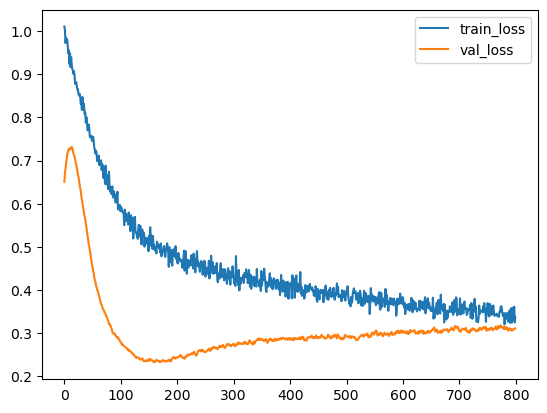

In [ ]:
plt.plot(history733.history['loss'])
plt.plot(history733.history['val_loss'])
plt.legend(['train_loss', 'val_loss'])

In [109]:
# Obtenemos las predicciones y deshacemos las transformaciones StandardScaler
y_pred_train_733 = scaler_y_models[733].inverse_transform(model_733.predict(Xs_tr733))
y_pred_val_733 = scaler_y_models[733].inverse_transform(model_733.predict(Xs_va733))

# Mostramos los R^2
print(f"R^2 Train = {R2_score(y_train[733][4:], y_pred_train_733)}")
print(f"R^2 Validación = {R2_score(y_val[733], y_pred_val_733)}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
R^2 Train = 0.7102270126342773
R^2 Validación = 0.17742383480072021


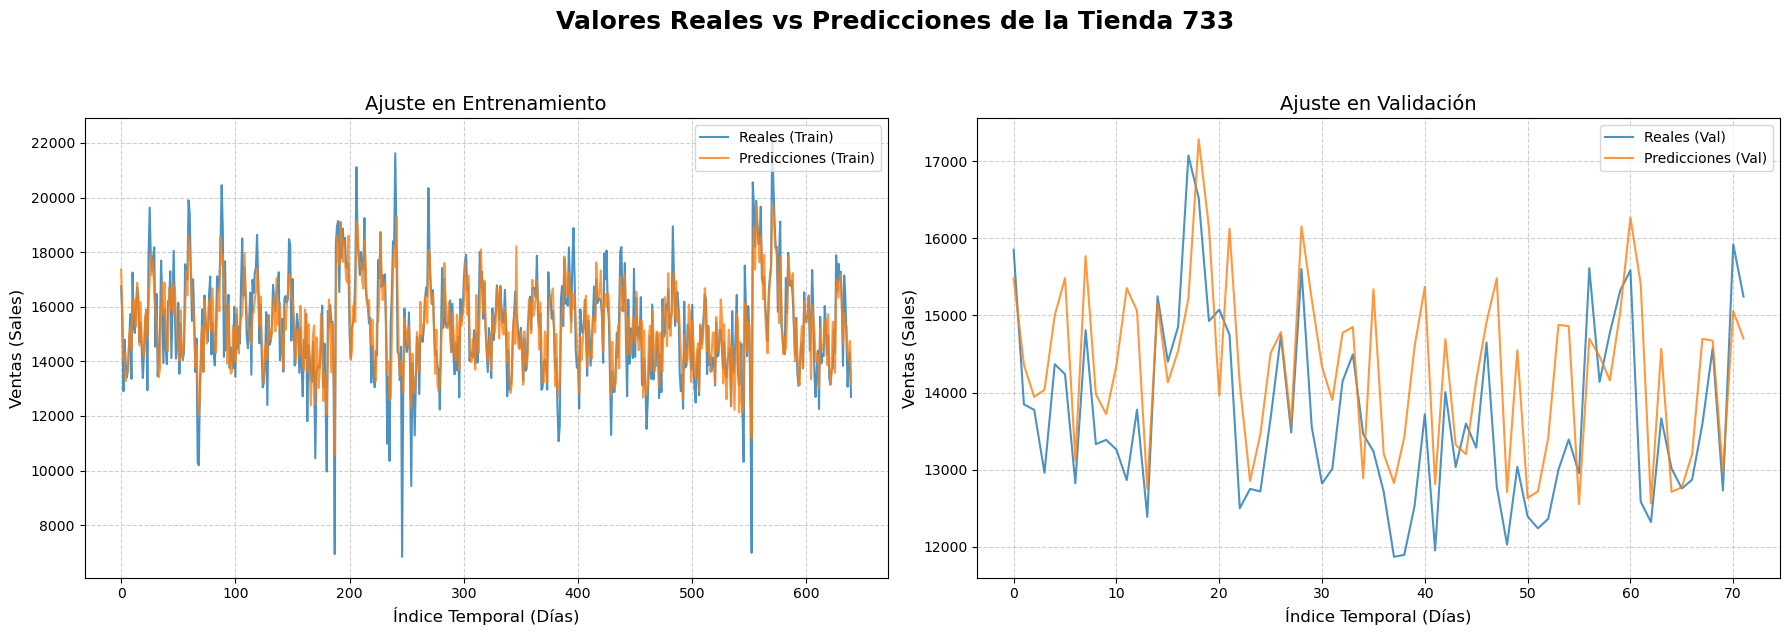

In [111]:
# Definimos el ID de la tienda actual para el título
tienda_id = 733

# 1. Configurar la figura y la matriz de subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# 2. Añadir el título general centrado
fig.suptitle(f'Valores Reales vs Predicciones de la Tienda {tienda_id}', fontsize=18, fontweight='bold', y=1.05)

# ---------------------------------------------------------
# Subplot Izquierdo: Datos de Entrenamiento
# ---------------------------------------------------------
# Usamos .values en los reales para ignorar el índice de Pandas y alinearlo con el array de NumPy
# Usamos .flatten() en las predicciones porque Keras devuelve una matriz (N, 1) y plt prefiere un vector (N,)
axes[0].plot(y_train[tienda_id][4:].values, label='Reales (Train)', color='#1f77b4', linewidth=1.5, alpha=0.8)
axes[0].plot(y_pred_train_733.flatten(), label='Predicciones (Train)', color='#ff7f0e', linewidth=1.5, alpha=0.8)

axes[0].set_title('Ajuste en Entrenamiento', fontsize=14)
axes[0].set_xlabel('Índice Temporal (Días)', fontsize=12)
axes[0].set_ylabel('Ventas (Sales)', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# ---------------------------------------------------------
# Subplot Derecho: Datos de Validación
# ---------------------------------------------------------
axes[1].plot(y_val[tienda_id].values, label='Reales (Val)', color='#1f77b4', linewidth=1.5, alpha=0.8)
axes[1].plot(y_pred_val_733.flatten(), label='Predicciones (Val)', color='#ff7f0e', linewidth=1.5, alpha=0.8)

axes[1].set_title('Ajuste en Validación', fontsize=14)
axes[1].set_xlabel('Índice Temporal (Días)', fontsize=12)
axes[1].set_ylabel('Ventas (Sales)', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

# 3. Ajustar el diseño para que no se superpongan elementos y mostrar
plt.tight_layout()
plt.show()

In [112]:
# Guardamos el modelo
model_733.save('trained models/modelo_tienda_733.keras')

# Guardamos el objeto standard scaler
with open('scaler_y/scaler_y_tienda_733.pkl', 'wb') as f:
    pickle.dump(scaler_y_models[733], f)

### <font color="#CA3532"> **6.9. Modelo tienda 769**

In [ ]:
# Cargar el modelo desde el disco
#model_769 = load_model('trained models/modelo_tienda_769.keras')

# Cargamos los modelos standard scaler
# with open('scaler_y/scaler_y_tienda_769.pkl', 'rb') as f:
#     scaler_y_models[769] = pickle.load(f)

In [113]:
x_769 = concatenate([embedding1, embedding2, embedding3, input3, input4])
x2_769 = LSTM(units=10, activation='relu')(x_769)
#x2_769 = Dropout(0.4)(x2_769)
x3_769 = Dense(units=7)(x2_769)
#x3_769 = Dropout(0.2)(x3_769)
x4_769 = Dense(units=1)(x3_769)

model_769 = Model(inputs=[input0, input1, input2, input3, input4], outputs=x4_769)
model_769.compile(loss="mean_squared_error", optimizer=optimizers.Adam(learning_rate=0.0001))

In [114]:
Xs_tr769, y_tr769 = Xs_tr[769], y_train_final[769]
Xs_va769, y_va769 = Xs_va[769], y_val_final[769]

history769 = model_769.fit(Xs_tr769, y_tr769, batch_size=32, epochs=500, validation_data=(Xs_va769, y_va769))

Epoch 1/500


20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - loss: 1.5502 - val_loss: 3.4792
Epoch 2/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.4470 - val_loss: 3.2266
Epoch 3/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1.3586 - val_loss: 3.0163
Epoch 4/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.2875 - val_loss: 2.8300
Epoch 5/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 1.2283 - val_loss: 2.6598
Epoch 6/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.1795 - val_loss: 2.5067
Epoch 7/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.1362 - val_loss: 2.3759
Epoch 8/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.1013 - val_loss: 2.2508
Epoch 9/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.0699 - val_loss: 2.1400
Epoch 10/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0435 - val_loss: 2.0343
Epoch 11/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0191 - val_loss: 1.9411
Epoch 12/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0

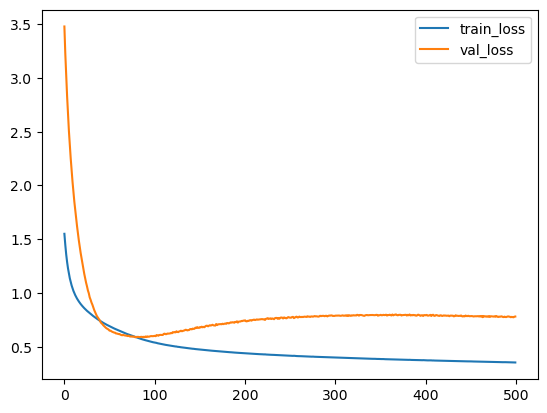

In [115]:
plt.plot(history769.history['loss'])
plt.plot(history769.history['val_loss'])
plt.legend(['train_loss', 'val_loss'])

In [116]:
# Obtenemos las predicciones y deshacemos las transformaciones StandardScaler
y_pred_train_769 = scaler_y_models[769].inverse_transform(model_769.predict(Xs_tr769))
y_pred_val_769 = scaler_y_models[769].inverse_transform(model_769.predict(Xs_va769))

# Mostramos los R^2
print(f"R^2 Train = {R2_score(y_train[769][4:], y_pred_train_769)}")
print(f"R^2 Validación = {R2_score(y_val[769], y_pred_val_769)}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 491ms/step
R^2 Train = 0.6390796899795532
R^2 Validación = 0.05452495813369751


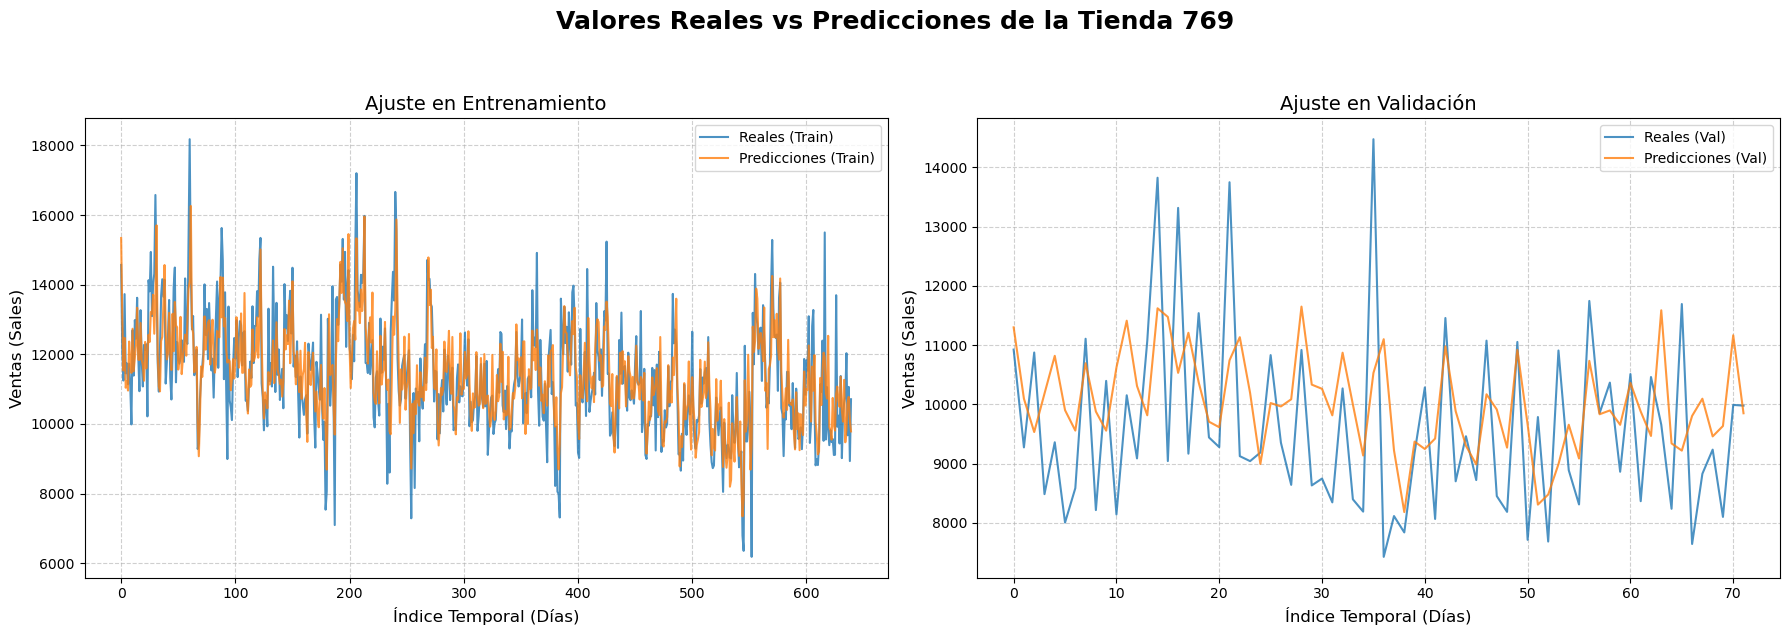

In [117]:
# Definimos el ID de la tienda actual para el título
tienda_id = 769

# 1. Configurar la figura y la matriz de subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# 2. Añadir el título general centrado
fig.suptitle(f'Valores Reales vs Predicciones de la Tienda {tienda_id}', fontsize=18, fontweight='bold', y=1.05)

# ---------------------------------------------------------
# Subplot Izquierdo: Datos de Entrenamiento
# ---------------------------------------------------------
# Usamos .values en los reales para ignorar el índice de Pandas y alinearlo con el array de NumPy
# Usamos .flatten() en las predicciones porque Keras devuelve una matriz (N, 1) y plt prefiere un vector (N,)
axes[0].plot(y_train[tienda_id][4:].values, label='Reales (Train)', color='#1f77b4', linewidth=1.5, alpha=0.8)
axes[0].plot(y_pred_train_769.flatten(), label='Predicciones (Train)', color='#ff7f0e', linewidth=1.5, alpha=0.8)

axes[0].set_title('Ajuste en Entrenamiento', fontsize=14)
axes[0].set_xlabel('Índice Temporal (Días)', fontsize=12)
axes[0].set_ylabel('Ventas (Sales)', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# ---------------------------------------------------------
# Subplot Derecho: Datos de Validación
# ---------------------------------------------------------
axes[1].plot(y_val[tienda_id].values, label='Reales (Val)', color='#1f77b4', linewidth=1.5, alpha=0.8)
axes[1].plot(y_pred_val_769.flatten(), label='Predicciones (Val)', color='#ff7f0e', linewidth=1.5, alpha=0.8)

axes[1].set_title('Ajuste en Validación', fontsize=14)
axes[1].set_xlabel('Índice Temporal (Días)', fontsize=12)
axes[1].set_ylabel('Ventas (Sales)', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

# 3. Ajustar el diseño para que no se superpongan elementos y mostrar
plt.tight_layout()
plt.show()

In [118]:
# Guardamos el modelo
model_769.save('trained models/modelo_tienda_769.keras')

# Guardamos el objeto standard scaler
with open('scaler_y/scaler_y_tienda_769.pkl', 'wb') as f:
    pickle.dump(scaler_y_models[769], f)

## <font color="#CA3532"> **7. Resultados y conclusiones**

A continuación, a partir de cada modelo de cada tienda obtendremos las predicciones autorregresivas para el año 2015 de cada tienda. Mostraremos una tabla final que incluirá los $R^2$ de los datos train, validación y test de cada tienda.

In [119]:
# Dividimos los datos en función de las columnas para que cuadren con la arquitectura de la red neuronal
semana_test = {}
estado_vacaciones_test = {}
mes_test = {}
binarias_test = {}
#numericas_test = {}

for tienda in tiendas:
    # Variables categoricas multiclase
    semana_test[tienda] = X_test_final[tienda][:,:,0]
    estado_vacaciones_test[tienda] = X_test_final[tienda][:,:,3]
    mes_test[tienda] = X_test_final[tienda][:,:,5]

    # Variables binarias
    binarias_test[tienda] = X_test_final[tienda][:,:,[1,2,4]]

    # Variables numéricas
    #numericas_test[tienda] = X_test_final[tienda][:,:,6:]

Obtenemos las predicciones asumiendo que los datos de test no los vamos a disponer al final del día. Es decir, para predecir en el instante t, no tendremos a mano los datos de las ventas en ninguna fecha anterior. Dicho de otro modo, para realizar las predicciones de forma autorregresiva, las variables numéricas (lag de Sales) las obtendremos a partir de las predicciones realizadas. El resto de variables sí que las tenemos a mano porque las conocemos de antemano.

In [122]:
models = {}
for tienda in tiendas:
    model = load_model('trained models/modelo_tienda_'+str(tienda)+'.keras')
    models[tienda] = model

In [123]:
# Diccionario para guardar las predicciones finales (desnormalizadas) de cada tienda
predicciones_test_finales = {}

# Las columnas exactas que usaste para entrenar el StandardScaler de X
cols_a_escalar = X_train[1].columns[-4:] 

for tienda in tiendas:
    # 1. Inicializamos nuestro histórico real con los datos de Train y Validación originales (SIN ESCALAR)
    # Convertimos a lista para poder ir haciendo .append() fácilmente
    y_historico = list(y_train[tienda].values) + list(y_val[tienda].values)
    
    # Lista temporal para ir guardando las predicciones de esta tienda
    y_pred_test = []
    
    # 2. Bucle Autorregresivo: Iteramos paso a paso sobre los 198 días de test
    num_dias_test = len(semana_test[tienda]) # Esto será 198
    
    for i in range(num_dias_test):
        # T es el índice del "día actual" que queremos predecir dentro de nuestro histórico
        T = len(y_historico) 
        
        # A. CONSTRUIR LA RAMA NUMÉRICA PARA LA VENTANA ACTUAL (5 días)
        # Reconstruimos los lags [1, 2, 7, 14] para los días [T-4, T-3, T-2, T-1, T]
        ventana_num = []
        for d in range(T - 4, T + 1): 
            lag1 = y_historico[d - 1]
            lag2 = y_historico[d - 2]
            lag7 = y_historico[d - 7]
            lag14 = y_historico[d - 14]
            ventana_num.append([lag1, lag2, lag7, lag14])
            
        # Convertimos a DataFrame para que el StandardScaler no lance advertencias (warnings)
        df_ventana = pd.DataFrame(ventana_num, columns=cols_a_escalar)
        
        # Escalamos la matriz de 5x4 y le damos la forma (1, 5, 4) para Keras
        ventana_num_scaled = scaler_models[tienda].transform(df_ventana)
        input4_i = ventana_num_scaled.reshape(1, 5, 4)
        
        # B. EXTRAER LAS RAMAS CATEGÓRICAS Y BINARIAS PARA ESTE PASO 'i'
        # Seleccionamos la fila 'i' conservando las dimensiones (1, 5) o (1, 5, 3)
        input0_i = semana_test[tienda][i:i+1]
        input1_i = estado_vacaciones_test[tienda][i:i+1]
        input2_i = mes_test[tienda][i:i+1]
        input3_i = binarias_test[tienda][i:i+1]
        
        # C. PREDECIR EL DÍA 'i'
        # Le pasamos la lista de inputs exactamente en el orden de tu arquitectura
        pred_scaled = models[tienda].predict([input0_i, input1_i, input2_i, input3_i, input4_i], verbose=0)
        
        # D. DESHACER LA NORMALIZACIÓN DE LA PREDICCIÓN
        pred_raw = scaler_y_models[tienda].inverse_transform(pred_scaled)[0][0]
        
        # E. ACTUALIZAR HISTÓRICO
        # Añadimos la predicción cruda al histórico para que el modelo la use en el loop i+1
        y_historico.append(pred_raw)
        
        # Guardamos la predicción final en nuestra lista de test
        y_pred_test.append(pred_raw)
        
    # Guardamos el array de 198 predicciones para esta tienda
    predicciones_test_finales[tienda] = np.array(y_pred_test)

Calculamos los $R^2$ de los datos reales versus predicciones para las particiones train, validation y test.

In [124]:
r2_train = []
r2_val = []
r2_test = []

for tienda in tiendas:
    # Obtenemos las predicciones y deshacemos las transformaciones StandardScaler
    y_pred_train = scaler_y_models[tienda].inverse_transform(models[tienda].predict(Xs_tr[tienda]))
    y_pred_val = scaler_y_models[tienda].inverse_transform(models[tienda].predict(Xs_va[tienda]))
    y_pred_test = predicciones_test_finales[tienda]

    # Mostramos los R^2
    r2_train.append(R2_score(y_train[tienda][4:], y_pred_train))
    r2_val.append(R2_score(y_val[tienda], y_pred_val))
    r2_test.append(R2_score(y_test[tienda], y_pred_test))

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 299ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 271ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 353ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 386ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 302ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 288ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step


Mostramos para cada gráfica la comparación de los datos de test reales versus las predicciones autorregresivas.

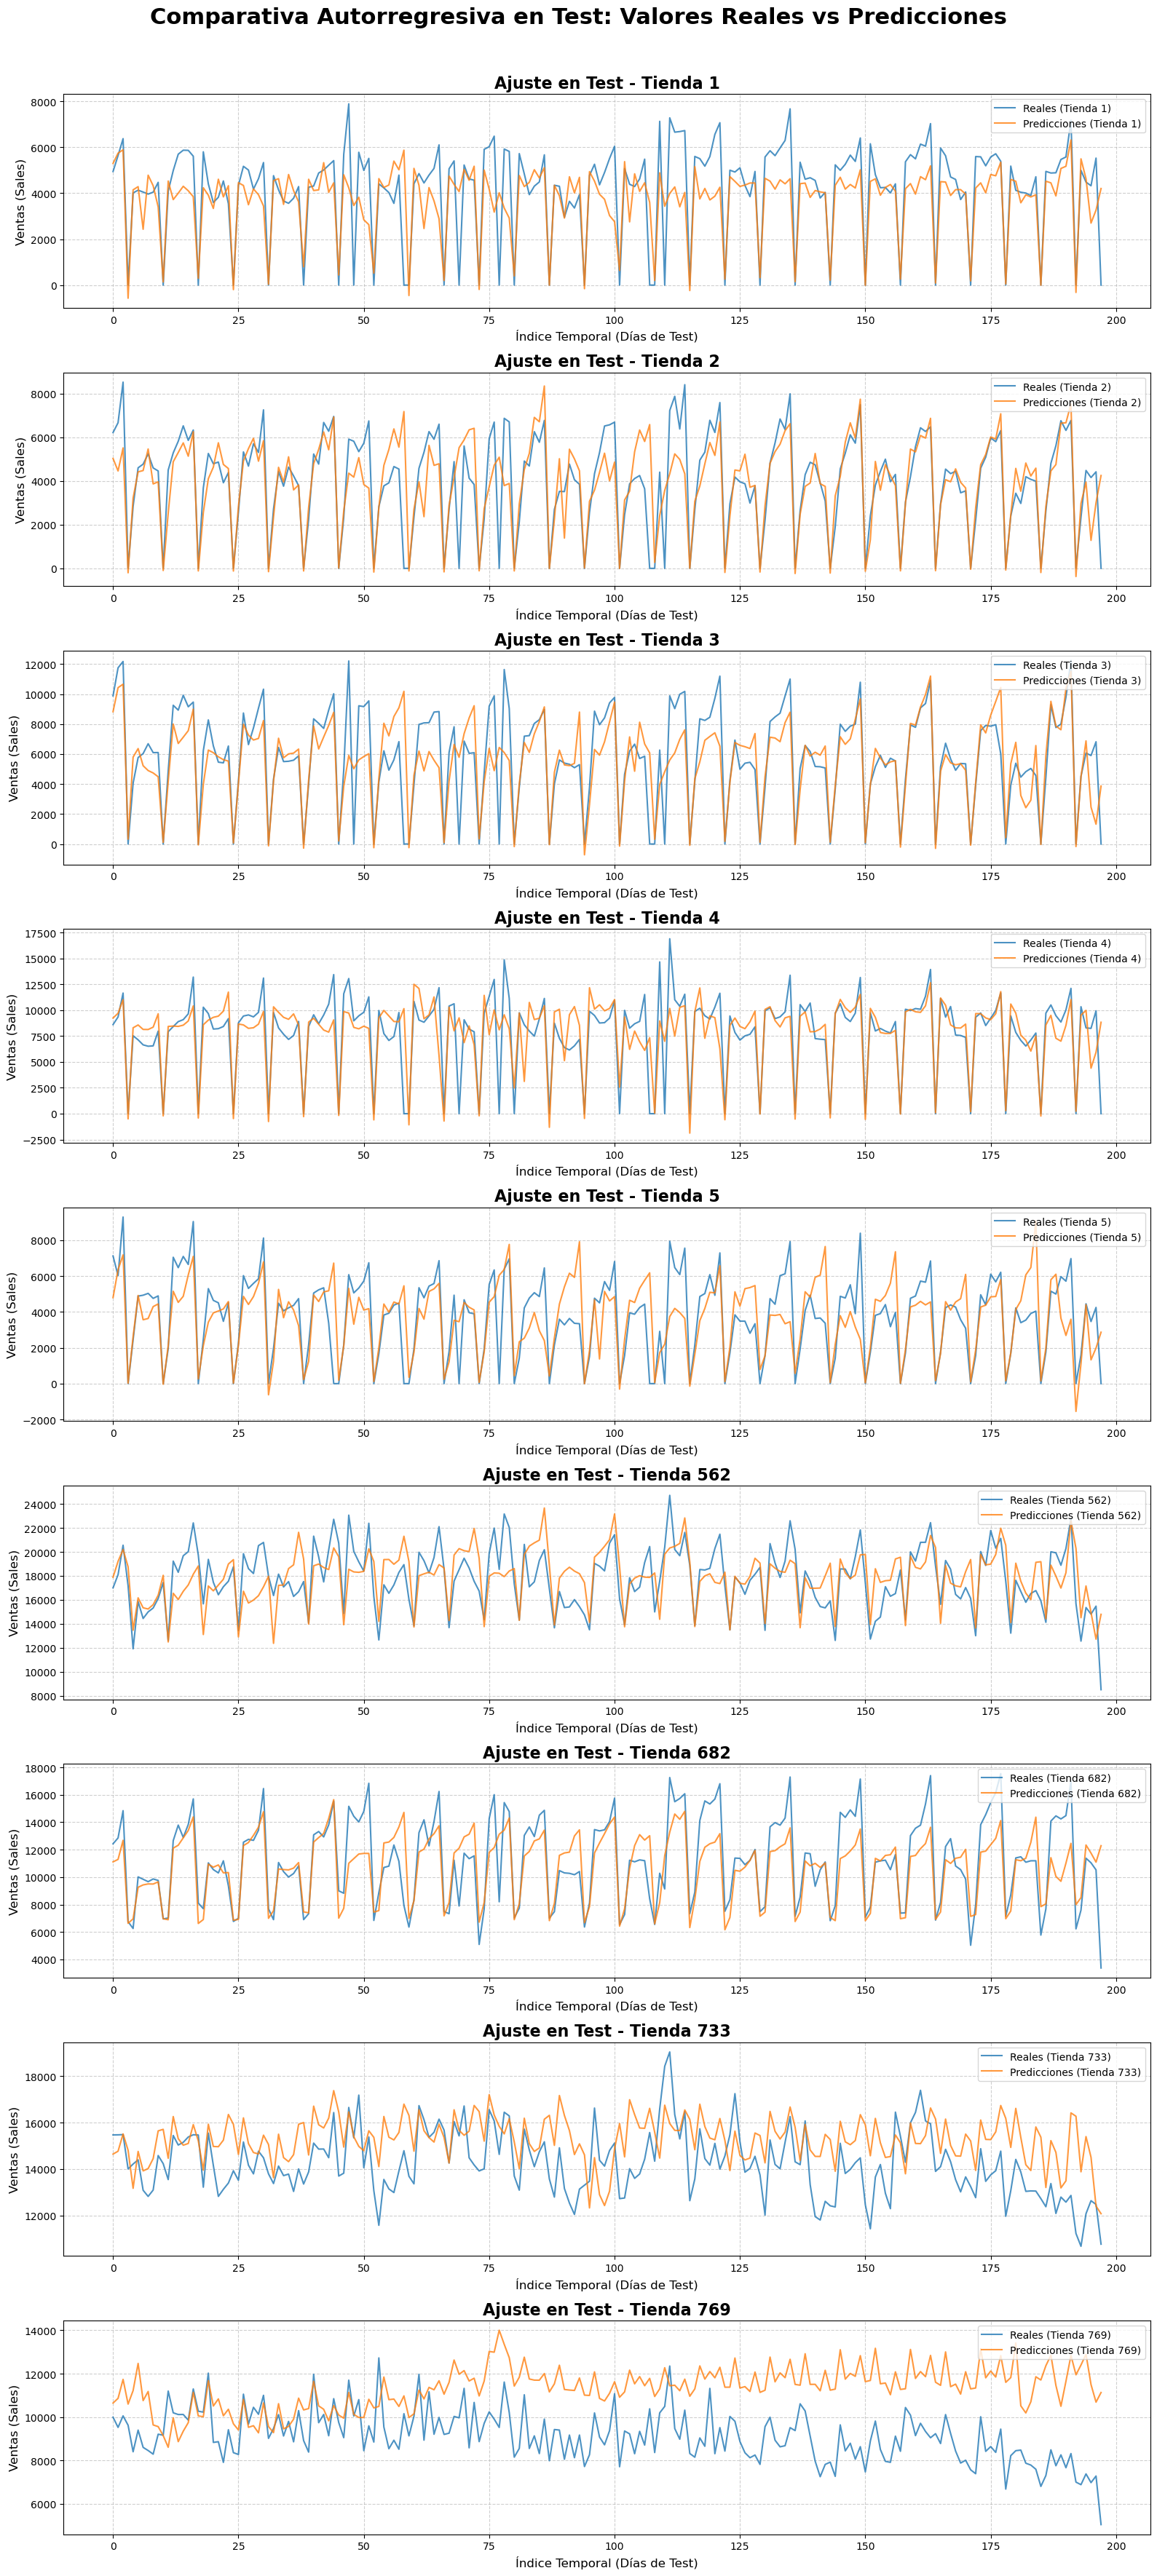

In [125]:
# 1. Configurar la figura (9 filas, 1 columna). 
# Aumentamos la altura a 35 (aprox 4 pulgadas por gráfico) para evitar superposiciones.
fig, axes = plt.subplots(nrows=9, ncols=1, figsize=(16, 35))

# 2. Añadir el título general
fig.suptitle('Comparativa Autorregresiva en Test: Valores Reales vs Predicciones', fontsize=22, fontweight='bold', y=1.01)

# 3. Bucle para generar un subplot por cada tienda
for i, tienda in enumerate(tiendas):
    # Seleccionamos el subgráfico correspondiente a la iteración actual
    ax = axes[i]
    
    # Extraemos los datos reales y las predicciones autorregresivas calculadas previamente
    reales_test = y_test[tienda].values
    predicciones_test = predicciones_test_finales[tienda]
    
    # Ploteamos ambas series
    ax.plot(reales_test, label=f'Reales (Tienda {tienda})', color='#1f77b4', linewidth=1.5, alpha=0.8)
    ax.plot(predicciones_test, label=f'Predicciones (Tienda {tienda})', color='#ff7f0e', linewidth=1.5, alpha=0.8)

    # Formato y etiquetas individuales
    ax.set_title(f'Ajuste en Test - Tienda {tienda}', fontsize=16, fontweight='bold')
    ax.set_xlabel('Índice Temporal (Días de Test)', fontsize=12)
    ax.set_ylabel('Ventas (Sales)', fontsize=12)
    
    # Leyenda y rejilla
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)

# 4. Ajustar el diseño general y mostrar
plt.tight_layout()
plt.show()

Generamos una tabla final que recopila los resultados y los guardamos.

In [126]:
# 1. Crear el DataFrame estructurando los datos en un diccionario
df_resultados = pd.DataFrame({
    'R^2 Train': r2_train,
    'R^2 Validación': r2_val,
    'R^2 Test': r2_test
}, index=tiendas)

# 2. (Opcional) Darle un nombre al índice para que la tabla quede más presentable
df_resultados.index.name = 'Tienda'

# 3. Mostrar el resultado
display(df_resultados)

,R^2 Train,R^2 Validación,R^2 Test
Tienda,,,
1,0.924198,0.834563,0.537370
2,0.923331,0.893160,0.596200
3,0.902074,0.876455,0.613314
4,0.933749,0.820173,0.637842
5,0.930738,0.888081,0.402306
562,0.864920,0.784947,0.397614
682,0.884689,0.914222,0.613699
733,0.710227,0.177424,-0.448002
769,0.639080,0.054525,-4.140352


In [127]:
df_resultados.to_excel('resultados/resultados_r2_tiendas.xlsx', index=True)